# Week 10: Medical Data Standards — FHIR and DICOM
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Explain why healthcare interoperability is a patient safety issue, not just an IT problem (Understand)
2. Describe FHIR resources (Patient, Observation, Condition, ImagingStudy) and RESTful API operations (Apply)
3. Query a FHIR test server and create/read Patient and Observation resources in Python (Apply)
4. Parse DICOM files using pydicom -- extract metadata tags and display pixel data (Apply)
5. Compare HL7 v2, FHIR, and DICOM and explain when each standard applies (Analyze)

**Tools:** Google Colab (no GPU needed) + Gemini AI
**Dataset:** HAPI FHIR Public Test Server + pydicom built-in test files
**Libraries:** requests, pydicom, numpy, matplotlib
**Estimated Time:** 40-50 minutes

---

> **Clinical Scenario (Red Thread):** A 68-year-old woman with chest pain
> is rushed from a rural clinic (Hospital A) to the regional medical center
> (Hospital B). The ambulance carries a CD with her CT angiography and a paper
> folder of lab results. When Hospital B tries to open the CD, the viewer
> crashes -- incompatible DICOM format. The ER doctor calls Hospital A for the
> blood panel, but Hospital A's EHR cannot export structured data, only a scanned
> PDF. The cardiologist must decide: catheterization or thrombolysis? She has no
> imaging, no prior medications list, no allergy history. This is not a technology
> failure -- it is an INTEROPERABILITY failure. Patients die not because data
> does not exist, but because systems cannot share it.
>
> **This week:** We learn the two foundational data standards that make healthcare
> AI possible -- FHIR for clinical data exchange and DICOM for medical imaging.
> We will query a live FHIR server, read real DICOM files, apply CT windowing,
> and build the bridge between clinical data and imaging data.


## 0. Environment Setup

This week is a **data infrastructure** week -- no deep learning, no GPU needed.
We work with two types of medical data standards:

**Key libraries:**
- **requests**: HTTP client for querying FHIR REST APIs (same library you would use for any web API)
- **pydicom**: The standard Python library for reading, writing, and manipulating DICOM medical imaging files
- **numpy**: Array operations for DICOM pixel data
- **matplotlib**: Visualization of medical images with proper windowing

**No GPU required.** All exercises are CPU-based: API calls, file parsing, and image display.

**Clinical framing:** Every library maps to the hospital transfer scenario:
- `requests` = the tool Hospital B uses to query Hospital A's FHIR server
- `pydicom` = the tool to open the CT scan from the CD
- `matplotlib` = the radiologist's window/level controls


In [1]:
# ============================================================
# Section 0a: Install additional libraries
# ============================================================
!pip install pydicom requests --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.1 MB/s eta 0:00:00


In [2]:
# ============================================================
# Section 0b: Imports
# ============================================================
import os
import json
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pydicom
from pydicom.data import get_testdata_file

import warnings
warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid")

print("All libraries imported successfully!")
print(f"pydicom version: {pydicom.__version__}")
print(f"numpy version:   {np.__version__}")
print()
print("No GPU needed this week -- all CPU-based.")
print("Focus: data standards (FHIR + DICOM), not model training.")


All libraries imported successfully!
pydicom version: 3.0.2
numpy version:   2.0.2

No GPU needed this week -- all CPU-based.
Focus: data standards (FHIR + DICOM), not model training.


In [3]:
# ============================================================
# Section 0c: Test FHIR Server Connectivity
# ============================================================
# HAPI FHIR is a free, public, standards-compliant FHIR R4 server
# used worldwide for development and testing.
# NOTE: This is a TEST server -- data is NOT real patient data and
#       may be reset periodically.

FHIR_BASE = "https://hapi.fhir.org/baseR4"

try:
    resp = requests.get(
        f"{FHIR_BASE}/metadata",
        headers={"Accept": "application/fhir+json"},
        timeout=15
    )
    if resp.status_code == 200:
        metadata = resp.json()
        print("HAPI FHIR Server: CONNECTED")
        print(f"  URL:      {FHIR_BASE}")
        print(f"  FHIR Ver: {metadata.get('fhirVersion', 'unknown')}")
        print(f"  Status:   {metadata.get('status', 'unknown')}")
        print(f"  Software: {metadata.get('software', {}).get('name', 'unknown')}")
        FHIR_AVAILABLE = True
    else:
        print(f"HAPI FHIR Server returned status {resp.status_code}")
        FHIR_AVAILABLE = False
except Exception as e:
    print(f"Could not connect to HAPI FHIR: {e}")
    print("Will use offline FHIR JSON examples as fallback.")
    FHIR_AVAILABLE = False

print()
print("Clinical context: This is the same API pattern that Hospital B")
print("would use to query Hospital A for the patient's clinical data.")


HAPI FHIR Server: CONNECTED
  URL:      https://hapi.fhir.org/baseR4
  FHIR Ver: 4.0.1
  Status:   active
  Software: HAPI FHIR Server

Clinical context: This is the same API pattern that Hospital B
would use to query Hospital A for the patient's clinical data.


In [4]:
# ============================================================
# Section 0d: Verify DICOM Test Files
# ============================================================
# pydicom ships with built-in test files -- no download needed.

try:
    ct_file = get_testdata_file("CT_small.dcm")
    mr_file = get_testdata_file("MR_small.dcm")
    print("DICOM test files available:")
    print(f"  CT file: {os.path.basename(ct_file)}")
    print(f"  MR file: {os.path.basename(mr_file)}")
    DICOM_AVAILABLE = True
except Exception as e:
    print(f"Could not locate pydicom test files: {e}")
    print("Some DICOM exercises may use synthetic data.")
    DICOM_AVAILABLE = False
    ct_file = None
    mr_file = None

print()
print("Clinical context: These are sample DICOM files like the ones")
print("stored on Hospital A's CD that crashed Hospital B's viewer.")


DICOM test files available:
  CT file: CT_small.dcm
  MR file: MR_small.dcm

Clinical context: These are sample DICOM files like the ones
stored on Hospital A's CD that crashed Hospital B's viewer.


## 1. FHIR Resource Exploration

**FHIR** (Fast Healthcare Interoperability Resources) is a modern healthcare
data standard built on RESTful APIs and JSON. Think of it as "the web API
for healthcare data."

Every piece of clinical information is a **Resource** -- a self-contained
JSON object representing one healthcare concept:
- **Patient**: demographics (name, DOB, gender, address)
- **Observation**: lab results, vitals (troponin, blood pressure, heart rate)
- **Condition**: diagnoses (hypertension, diabetes, chest pain)
- **MedicationRequest**: prescriptions (metformin, aspirin)
- **ImagingStudy**: link to DICOM imaging data

**For our 68-year-old patient:**
- Patient resource = her identity and demographics
- Observation resources = her troponin level, blood glucose, blood pressure
- Condition resources = her diagnoses (chest pain, hypertension, diabetes)
- ImagingStudy resource = link to her CT angiography DICOM study

> **Corresponds to Part 2, Slides S21-S22**


In [5]:
# ============================================================
# Section 1a: Explore a FHIR Patient Resource
# ============================================================
# A FHIR Patient resource in JSON -- this is what Hospital B
# receives when querying Hospital A for the patient's demographics.

sample_patient = {
    "resourceType": "Patient",
    "id": "example-68f",
    "meta": {
        "versionId": "1",
        "lastUpdated": "2026-02-08T10:30:00Z"
    },
    "name": [
        {
            "use": "official",
            "family": "Chen",
            "given": ["Mei-Ling"]
        }
    ],
    "gender": "female",
    "birthDate": "1958-03-15",
    "address": [
        {
            "use": "home",
            "city": "Tainan",
            "state": "Taiwan",
            "country": "TW"
        }
    ],
    "identifier": [
        {
            "system": "https://www.nhi.gov.tw/",
            "value": "A123456789"
        }
    ]
}

print("FHIR Patient Resource")
print("=" * 65)
print(json.dumps(sample_patient, indent=2))
print()
print("Key fields:")
print(f"  resourceType: {sample_patient['resourceType']}")
print(f"  id:           {sample_patient['id']}")
print(f"  name:         {sample_patient['name'][0]['family']}, {sample_patient['name'][0]['given'][0]}")
print(f"  gender:       {sample_patient['gender']}")
print(f"  birthDate:    {sample_patient['birthDate']}")
print(f"  address:      {sample_patient['address'][0]['city']}, {sample_patient['address'][0]['country']}")
print()
print("Clinical context: This structured JSON replaces the faxed")
print("paper demographics that Hospital B could not read.")


FHIR Patient Resource
{
  "resourceType": "Patient",
  "id": "example-68f",
  "meta": {
    "versionId": "1",
    "lastUpdated": "2026-02-08T10:30:00Z"
  },
  "name": [
    {
      "use": "official",
      "family": "Chen",
      "given": [
        "Mei-Ling"
      ]
    }
  ],
  "gender": "female",
  "birthDate": "1958-03-15",
  "address": [
    {
      "use": "home",
      "city": "Tainan",
      "state": "Taiwan",
      "country": "TW"
    }
  ],
  "identifier": [
    {
      "system": "https://www.nhi.gov.tw/",
      "value": "A123456789"
    }
  ]
}

Key fields:
  resourceType: Patient
  id:           example-68f
  name:         Chen, Mei-Ling
  gender:       female
  birthDate:    1958-03-15
  address:      Tainan, TW

Clinical context: This structured JSON replaces the faxed
paper demographics that Hospital B could not read.


In [6]:
# ============================================================
# Section 1b: Explore a FHIR Observation Resource
# ============================================================
# A FHIR Observation resource -- the patient's troponin level
# coded with LOINC (Logical Observation Identifiers Names and Codes).

sample_observation = {
    "resourceType": "Observation",
    "id": "troponin-001",
    "status": "final",
    "category": [
        {
            "coding": [
                {
                    "system": "http://terminology.hl7.org/CodeSystem/observation-category",
                    "code": "laboratory",
                    "display": "Laboratory"
                }
            ]
        }
    ],
    "code": {
        "coding": [
            {
                "system": "http://loinc.org",
                "code": "6598-7",
                "display": "Troponin T.cardiac [Mass/volume] in Serum or Plasma"
            }
        ],
        "text": "Cardiac Troponin T"
    },
    "subject": {
        "reference": "Patient/example-68f",
        "display": "Chen, Mei-Ling"
    },
    "effectiveDateTime": "2026-02-08T08:15:00Z",
    "valueQuantity": {
        "value": 0.52,
        "unit": "ng/mL",
        "system": "http://unitsofmeasure.org",
        "code": "ng/mL"
    },
    "referenceRange": [
        {
            "high": {
                "value": 0.04,
                "unit": "ng/mL"
            },
            "text": "Normal: < 0.04 ng/mL"
        }
    ],
    "interpretation": [
        {
            "coding": [
                {
                    "system": "http://terminology.hl7.org/CodeSystem/v3-ObservationInterpretation",
                    "code": "HH",
                    "display": "Critical high"
                }
            ]
        }
    ]
}

print("FHIR Observation Resource (Troponin T)")
print("=" * 65)
print(json.dumps(sample_observation, indent=2, ensure_ascii=False))
print()
print("Key clinical information:")
print(f"  Test:           {sample_observation['code']['text']}")
print(f"  LOINC code:     {sample_observation['code']['coding'][0]['code']}")
print(f"  Value:          {sample_observation['valueQuantity']['value']} {sample_observation['valueQuantity']['unit']}")
print(f"  Reference max:  {sample_observation['referenceRange'][0]['high']['value']} {sample_observation['referenceRange'][0]['high']['unit']}")
print(f"  Interpretation: {sample_observation['interpretation'][0]['coding'][0]['display']}")
print(f"  Patient:        {sample_observation['subject']['display']}")
print()
print("Troponin = 0.52 ng/mL (normal < 0.04) => CRITICAL HIGH")
print("This is the lab result the cardiologist desperately needed.")
print("With FHIR, it arrives in seconds. Without it, she waits for a fax.")


FHIR Observation Resource (Troponin T)
{
  "resourceType": "Observation",
  "id": "troponin-001",
  "status": "final",
  "category": [
    {
      "coding": [
        {
          "system": "http://terminology.hl7.org/CodeSystem/observation-category",
          "code": "laboratory",
          "display": "Laboratory"
        }
      ]
    }
  ],
  "code": {
    "coding": [
      {
        "system": "http://loinc.org",
        "code": "6598-7",
        "display": "Troponin T.cardiac [Mass/volume] in Serum or Plasma"
      }
    ],
    "text": "Cardiac Troponin T"
  },
  "subject": {
    "reference": "Patient/example-68f",
    "display": "Chen, Mei-Ling"
  },
  "effectiveDateTime": "2026-02-08T08:15:00Z",
  "valueQuantity": {
    "value": 0.52,
    "unit": "ng/mL",
    "system": "http://unitsofmeasure.org",
    "code": "ng/mL"
  },
  "referenceRange": [
    {
      "high": {
        "value": 0.04,
        "unit": "ng/mL"
      },
      "text": "Normal: < 0.04 ng/mL"
    }
  ],
  "interpret

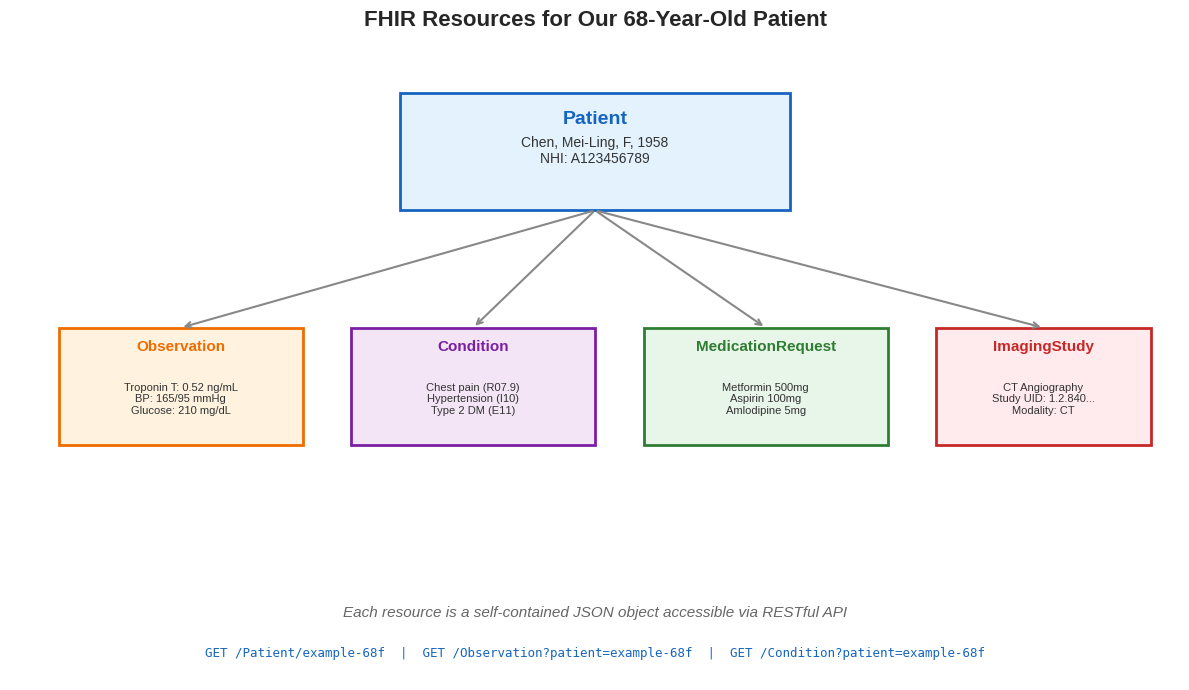

Each FHIR resource is one piece of the patient's clinical story.
Together, they give the cardiologist the full picture.


In [7]:
# ============================================================
# Section 1c: Visualize FHIR Resource Structure
# ============================================================
# Map out the FHIR resource types relevant to our patient scenario.

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("FHIR Resources for Our 68-Year-Old Patient",
             fontsize=16, fontweight="bold", pad=20)

# Patient resource (center top)
patient_box = plt.Rectangle((4, 6), 4, 1.5, facecolor="#E3F2FD",
                              edgecolor="#1565C0", linewidth=2, zorder=2)
ax.add_patch(patient_box)
ax.text(6, 7.1, "Patient", fontsize=14, fontweight="bold", ha="center",
        color="#1565C0")
ax.text(6, 6.6, "Chen, Mei-Ling, F, 1958\nNHI: A123456789",
        fontsize=10, ha="center", color="#333333")

# Connected resources
resources = [
    (0.5, 3, 2.5, 1.5, "Observation", "Troponin T: 0.52 ng/mL\nBP: 165/95 mmHg\nGlucose: 210 mg/dL",
     "#FFF3E0", "#EF6C00"),
    (3.5, 3, 2.5, 1.5, "Condition", "Chest pain (R07.9)\nHypertension (I10)\nType 2 DM (E11)",
     "#F3E5F5", "#7B1FA2"),
    (6.5, 3, 2.5, 1.5, "MedicationRequest", "Metformin 500mg\nAspirin 100mg\nAmlodipine 5mg",
     "#E8F5E9", "#2E7D32"),
    (9.5, 3, 2.2, 1.5, "ImagingStudy", "CT Angiography\nStudy UID: 1.2.840...\nModality: CT",
     "#FFEBEE", "#C62828"),
]

for x, y, w, h, title, content, fc, ec in resources:
    box = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec,
                          linewidth=2, zorder=2)
    ax.add_patch(box)
    ax.text(x + w / 2, y + h - 0.3, title, fontsize=11, fontweight="bold",
            ha="center", color=ec)
    ax.text(x + w / 2, y + 0.4, content, fontsize=8, ha="center",
            color="#333333")
    # Draw arrow from patient to resource
    ax.annotate("", xy=(x + w / 2, y + h), xytext=(6, 6),
                arrowprops=dict(arrowstyle="->", color="#888888", lw=1.5))

# Legend
ax.text(6, 0.8, "Each resource is a self-contained JSON object accessible via RESTful API",
        fontsize=11, ha="center", style="italic", color="#666666")
ax.text(6, 0.3, "GET /Patient/example-68f  |  GET /Observation?patient=example-68f  |  GET /Condition?patient=example-68f",
        fontsize=9, ha="center", family="monospace", color="#1565C0")

plt.tight_layout()
plt.show()

print("Each FHIR resource is one piece of the patient's clinical story.")
print("Together, they give the cardiologist the full picture.")


## 2. Search FHIR Server

Now we move from local JSON examples to a **live FHIR server**. The HAPI FHIR
public test server at https://hapi.fhir.org/baseR4/ is a free, standards-compliant
FHIR R4 endpoint used worldwide for development and testing.

**FHIR search** uses URL query parameters -- the same pattern as any web API:
- `GET /Patient?name=Smith` -- search patients by name
- `GET /Patient?name=Smith&_count=5` -- limit to 5 results
- `GET /Observation?patient=123&code=8867-4` -- heart rate for patient 123

The server returns a **Bundle** -- a FHIR resource that wraps search results.

**Important:** HAPI FHIR is a TEST server. Data is not real patient data
and may be reset periodically. Do not store important data here.

> **Corresponds to Lab 1, Slide S34**


In [8]:
# ============================================================
# Section 2a: Search for Patients by Name
# ============================================================
# Query HAPI FHIR for patients named "Smith" -- the same API
# pattern Hospital B would use to search Hospital A.

FHIR_BASE = "https://hapi.fhir.org/baseR4"

try:
    search_url = f"{FHIR_BASE}/Patient"
    params = {
        "name": "Smith",
        "_count": 5,
        "_sort": "-_lastUpdated"
    }
    headers = {"Accept": "application/fhir+json"}

    print("Searching HAPI FHIR for patients named 'Smith'...")
    print(f"  URL: {search_url}?name=Smith&_count=5")
    print()

    resp = requests.get(search_url, params=params, headers=headers, timeout=15)
    resp.raise_for_status()

    bundle = resp.json()
    total = bundle.get("total", "unknown")
    entries = bundle.get("entry", [])

    print(f"Bundle type:    {bundle.get('type', 'unknown')}")
    print(f"Total matches:  {total}")
    print(f"Returned:       {len(entries)} entries")
    print()
    print(f"{'#':<4} {'ID':<12} {'Name':<30} {'Gender':<10} {'BirthDate':<12}")
    print("-" * 68)

    for i, entry in enumerate(entries):
        resource = entry.get("resource", {})
        pid = resource.get("id", "N/A")
        names = resource.get("name", [{}])
        if names:
            family = names[0].get("family", "")
            given = " ".join(names[0].get("given", []))
            full_name = f"{family}, {given}" if given else family
        else:
            full_name = "N/A"
        gender = resource.get("gender", "N/A")
        birth = resource.get("birthDate", "N/A")
        print(f"{i+1:<4} {pid:<12} {full_name:<30} {gender:<10} {birth:<12}")

    print()
    print("Each row is a FHIR Patient resource on the live server.")

except requests.exceptions.RequestException as e:
    print(f"Could not reach HAPI FHIR: {e}")
    print()
    print("Fallback: Using local sample Patient resource from Section 1.")
    print("The API pattern is identical -- only the data source changes.")
    entries = []


Searching HAPI FHIR for patients named 'Smith'...
  URL: https://hapi.fhir.org/baseR4/Patient?name=Smith&_count=5

Bundle type:    searchset
Total matches:  unknown
Returned:       5 entries

#    ID           Name                           Gender     BirthDate   
--------------------------------------------------------------------
1    2ff0b457-7fe8-4687-9efb-716b9c1f11f7 Smith, Thomas                  male       1957-11-18  
2    05c4846a-299b-41c3-b618-31e08c0a53c7 Smith, Henry                   male       1988-12-27  
3    cd0dd1d6-cf8a-475a-83da-dcf8422f1f36 Smith, Ethan                   male       1952-03-25  
4    6f8460e0-c50f-4ae5-98de-99fdedfba651 Smith, John                    male       1968-07-27  
5    17bf6112-5752-4d5f-81ff-904c12c7c744 Smith, Ava                     female     1974-08-20  

Each row is a FHIR Patient resource on the live server.


In [9]:
# ============================================================
# Section 2b: Understand the Bundle Response
# ============================================================
# A FHIR Bundle wraps search results with metadata.

try:
    if entries:
        print("FHIR Bundle Structure:")
        print("=" * 65)
        print(f"  resourceType: {bundle.get('resourceType')}")
        print(f"  type:         {bundle.get('type')}")
        print(f"  total:        {bundle.get('total')}")
        print(f"  entries:      {len(bundle.get('entry', []))}")
        print()

        # Show the first entry as formatted JSON (truncated)
        first_entry = entries[0]["resource"]
        print("First Patient resource (abbreviated):")
        print("-" * 65)
        abbreviated = {
            "resourceType": first_entry.get("resourceType"),
            "id": first_entry.get("id"),
            "name": first_entry.get("name", [{}])[:1],
            "gender": first_entry.get("gender"),
            "birthDate": first_entry.get("birthDate"),
        }
        print(json.dumps(abbreviated, indent=2))
    else:
        print("No entries returned. Showing local sample instead.")
        print(json.dumps(sample_patient, indent=2))

except NameError:
    print("Bundle not available (server offline). Using local sample.")
    print(json.dumps(sample_patient, indent=2))

print()
print("Clinical context: This is how Hospital B discovers the patient's")
print("records -- a structured search that returns machine-readable data,")
print("not a faxed PDF.")


FHIR Bundle Structure:
  resourceType: Bundle
  type:         searchset
  total:        None
  entries:      5

First Patient resource (abbreviated):
-----------------------------------------------------------------
{
  "resourceType": "Patient",
  "id": "2ff0b457-7fe8-4687-9efb-716b9c1f11f7",
  "name": [
    {
      "use": "official",
      "family": "Smith",
      "given": [
        "Thomas"
      ],
      "prefix": [
        "Mr"
      ]
    }
  ],
  "gender": "male",
  "birthDate": "1957-11-18"
}

Clinical context: This is how Hospital B discovers the patient's
records -- a structured search that returns machine-readable data,
not a faxed PDF.


## 3. Read a Specific Patient and Their Observations

After discovering a patient via search (Section 2), the next step is to
**read their full record** and **retrieve linked Observations** (lab results,
vital signs).

This is the two-step pattern that Hospital B would use:
1. `GET /Patient/{id}` -- read the patient's demographics
2. `GET /Observation?patient={id}` -- read all their lab results

FHIR links resources via **references** -- `Observation.subject.reference`
points to `Patient/{id}`. This creates a web of interconnected clinical data.

> **Corresponds to Lab 1, Slide S35**


In [10]:
# ============================================================
# Section 3a: Read a Specific Patient by ID
# ============================================================
# GET /Patient/{id} -- read one specific patient resource.

try:
    # Use the first patient from our search, or a known test ID
    if entries:
        patient_id = entries[0]["resource"]["id"]
    else:
        patient_id = "592912"  # A commonly available HAPI test patient

    read_url = f"{FHIR_BASE}/Patient/{patient_id}"
    print(f"Reading Patient: GET {read_url}")
    print()

    resp = requests.get(read_url, headers=headers, timeout=15)
    resp.raise_for_status()
    patient = resp.json()

    # Extract key fields
    names = patient.get("name", [{}])
    if names:
        family = names[0].get("family", "N/A")
        given = " ".join(names[0].get("given", [""]))
    else:
        family, given = "N/A", "N/A"

    print(f"Patient found:")
    print(f"  ID:         {patient.get('id')}")
    print(f"  Name:       {family}, {given}")
    print(f"  Gender:     {patient.get('gender', 'N/A')}")
    print(f"  BirthDate:  {patient.get('birthDate', 'N/A')}")
    print(f"  Active:     {patient.get('active', 'N/A')}")

    # Count extensions and identifiers
    identifiers = patient.get("identifier", [])
    extensions = patient.get("extension", [])
    print(f"  Identifiers: {len(identifiers)}")
    print(f"  Extensions:  {len(extensions)}")
    PATIENT_AVAILABLE = True

except Exception as e:
    print(f"Could not read patient: {e}")
    print("Using local sample patient.")
    patient_id = "example-68f"
    patient = sample_patient
    PATIENT_AVAILABLE = False

print()
print("Clinical context: Hospital B now has the patient's demographics.")
print("Next step: retrieve her lab results (Observations).")


Reading Patient: GET https://hapi.fhir.org/baseR4/Patient/2ff0b457-7fe8-4687-9efb-716b9c1f11f7

Patient found:
  ID:         2ff0b457-7fe8-4687-9efb-716b9c1f11f7
  Name:       Smith, Thomas
  Gender:     male
  BirthDate:  1957-11-18
  Active:     True
  Identifiers: 2
  Extensions:  0

Clinical context: Hospital B now has the patient's demographics.
Next step: retrieve her lab results (Observations).


In [11]:
# ============================================================
# Section 3b: Get Observations Linked to the Patient
# ============================================================
# GET /Observation?patient={id} -- all lab results for this patient.

try:
    obs_url = f"{FHIR_BASE}/Observation"
    obs_params = {
        "patient": patient_id,
        "_count": 10,
        "_sort": "-date"
    }

    print(f"Searching Observations: GET /Observation?patient={patient_id}&_count=10")
    print()

    resp = requests.get(obs_url, params=obs_params, headers=headers, timeout=15)
    resp.raise_for_status()
    obs_bundle = resp.json()

    obs_entries = obs_bundle.get("entry", [])
    print(f"Observations found: {obs_bundle.get('total', len(obs_entries))}")
    print()

    if obs_entries:
        print(f"{'#':<4} {'Code':<25} {'Value':<20} {'Date':<20}")
        print("-" * 70)
        for i, entry in enumerate(obs_entries[:10]):
            obs = entry.get("resource", {})
            # Extract code display text
            code_obj = obs.get("code", {})
            code_text = code_obj.get("text", "")
            if not code_text:
                codings = code_obj.get("coding", [{}])
                code_text = codings[0].get("display", "Unknown") if codings else "Unknown"
            code_text = code_text[:24]

            # Extract value
            vq = obs.get("valueQuantity", {})
            if vq:
                val_str = f"{vq.get('value', 'N/A')} {vq.get('unit', '')}"
            elif obs.get("valueCodeableConcept"):
                val_str = obs["valueCodeableConcept"].get("text", "coded")
            elif obs.get("valueString"):
                val_str = obs["valueString"][:19]
            else:
                val_str = "N/A"

            # Extract date
            date_str = obs.get("effectiveDateTime", obs.get("issued", "N/A"))
            if date_str and len(date_str) > 19:
                date_str = date_str[:19]

            print(f"{i+1:<4} {code_text:<25} {val_str:<20} {date_str:<20}")
    else:
        print("No observations found for this patient on HAPI.")
        print("This is normal -- test server data varies.")

except Exception as e:
    print(f"Could not retrieve observations: {e}")
    print()
    print("Fallback: Showing the local sample Observation from Section 1.")
    obs = sample_observation
    print(f"  Test:  {obs['code']['text']}")
    print(f"  Value: {obs['valueQuantity']['value']} {obs['valueQuantity']['unit']}")
    print(f"  Date:  {obs['effectiveDateTime']}")

print()
print("Clinical context: Two API calls = demographics + lab history.")
print("The cardiologist now has troponin, glucose, and blood pressure.")
print("No fax machine required.")


Searching Observations: GET /Observation?patient=2ff0b457-7fe8-4687-9efb-716b9c1f11f7&_count=10

Observations found: 6

#    Code                      Value                Date                
----------------------------------------------------------------------
1    Systolic BP               148 mm[Hg]           2026-05-03T17:01:33 
2    Diastolic BP              65 mm[Hg]            2026-05-03T17:01:33 
3    Heart rate                80 /min              2026-05-03T17:01:33 
4    Body temperature          36.6 Cel             2026-05-03T17:01:33 
5    SpO2                      94 %                 2026-05-03T17:01:33 
6    Body weight               81 kg                2026-05-03T17:01:33 

Clinical context: Two API calls = demographics + lab history.
The cardiologist now has troponin, glucose, and blood pressure.
No fax machine required.


## 4. Create a FHIR Observation

So far we have been **reading** data from the FHIR server. Now we **write**
data -- creating a new Observation resource via HTTP POST.

This is how a medical device (e.g., an ECG monitor, a blood glucose meter,
or a wearable sensor) reports data to the EHR:
1. Build a JSON Observation resource
2. POST it to the FHIR server
3. Server validates, assigns an ID, returns 201 Created

**LOINC codes** ensure the observation is semantically coded -- "heart rate"
is always code `8867-4`, no matter which device or hospital generates it.

> **Corresponds to Lab 1, Slide S36**


In [12]:
# ============================================================
# Section 4a: Build an Observation Resource
# ============================================================
# Create a heart rate observation for our patient.
# This is how a wearable device would report data to the EHR.

new_observation = {
    "resourceType": "Observation",
    "status": "final",
    "category": [
        {
            "coding": [
                {
                    "system": "http://terminology.hl7.org/CodeSystem/observation-category",
                    "code": "vital-signs",
                    "display": "Vital Signs"
                }
            ]
        }
    ],
    "code": {
        "coding": [
            {
                "system": "http://loinc.org",
                "code": "8867-4",
                "display": "Heart rate"
            }
        ],
        "text": "Heart Rate"
    },
    "subject": {
        "reference": f"Patient/{patient_id}"
    },
    "effectiveDateTime": "2026-02-08T09:00:00Z",
    "valueQuantity": {
        "value": 88,
        "unit": "beats/minute",
        "system": "http://unitsofmeasure.org",
        "code": "/min"
    }
}

print("New FHIR Observation (Heart Rate)")
print("=" * 65)
print(json.dumps(new_observation, indent=2))
print()
print("Key elements:")
print(f"  LOINC code: 8867-4 (Heart rate)")
print(f"  Value:      88 beats/minute")
print(f"  Patient:    {patient_id}")
print(f"  Status:     final")


New FHIR Observation (Heart Rate)
{
  "resourceType": "Observation",
  "status": "final",
  "category": [
    {
      "coding": [
        {
          "system": "http://terminology.hl7.org/CodeSystem/observation-category",
          "code": "vital-signs",
          "display": "Vital Signs"
        }
      ]
    }
  ],
  "code": {
    "coding": [
      {
        "system": "http://loinc.org",
        "code": "8867-4",
        "display": "Heart rate"
      }
    ],
    "text": "Heart Rate"
  },
  "subject": {
    "reference": "Patient/2ff0b457-7fe8-4687-9efb-716b9c1f11f7"
  },
  "effectiveDateTime": "2026-02-08T09:00:00Z",
  "valueQuantity": {
    "value": 88,
    "unit": "beats/minute",
    "system": "http://unitsofmeasure.org",
    "code": "/min"
  }
}

Key elements:
  LOINC code: 8867-4 (Heart rate)
  Value:      88 beats/minute
  Patient:    2ff0b457-7fe8-4687-9efb-716b9c1f11f7
  Status:     final


In [13]:
# ============================================================
# Section 4b: POST the Observation to HAPI FHIR
# ============================================================
# HTTP POST creates a new resource on the server.
# The server assigns an ID and returns 201 Created.

try:
    post_url = f"{FHIR_BASE}/Observation"
    post_headers = {
        "Content-Type": "application/fhir+json",
        "Accept": "application/fhir+json"
    }

    print(f"POSTing Observation to: {post_url}")
    print()

    resp = requests.post(
        post_url,
        json=new_observation,
        headers=post_headers,
        timeout=15
    )

    if resp.status_code == 201:
        created = resp.json()
        print(f"SUCCESS! Observation created.")
        print(f"  Status code:  {resp.status_code} Created")
        print(f"  Assigned ID:  {created.get('id', 'N/A')}")
        print(f"  Version:      {created.get('meta', {}).get('versionId', 'N/A')}")
        print(f"  Last Updated: {created.get('meta', {}).get('lastUpdated', 'N/A')}")
        print()
        print("The observation is now stored on the FHIR server and can be")
        print("retrieved by any authorized system using:")
        print(f"  GET /Observation/{created.get('id', 'XXX')}")
    else:
        print(f"Server returned: {resp.status_code}")
        print(f"Response: {resp.text[:200]}")

except Exception as e:
    print(f"Could not POST observation: {e}")
    print()
    print("This is expected if the server is temporarily unavailable.")
    print("The JSON structure above is correct -- you can POST it when")
    print("the server is back online.")

print()
print("Clinical context: This is how wearable devices from Prof. Lin's")
print("lab report ECG data to the hospital EHR -- structured, coded,")
print("and instantly available to any clinician.")


POSTing Observation to: https://hapi.fhir.org/baseR4/Observation

SUCCESS! Observation created.
  Status code:  201 Created
  Assigned ID:  132007811
  Version:      1
  Last Updated: 2026-05-04T05:44:38.065+00:00

The observation is now stored on the FHIR server and can be
retrieved by any authorized system using:
  GET /Observation/132007811

Clinical context: This is how wearable devices from Prof. Lin's
lab report ECG data to the hospital EHR -- structured, coded,
and instantly available to any clinician.


## 5. Load DICOM File and Extract Metadata

**DICOM** (Digital Imaging and Communications in Medicine) is the universal
standard for medical imaging. Every CT, MRI, X-ray, and ultrasound you have
ever seen in a hospital is stored as DICOM.

A DICOM file is **more than an image** -- it bundles:
- **Pixel data**: the actual image (a NumPy array)
- **Metadata tags**: patient info, acquisition parameters, equipment details

Each piece of metadata has a **tag** -- a (group, element) pair:
- `(0010, 0010)` = Patient Name
- `(0008, 0060)` = Modality (CT, MR, US, XR)
- `(0028, 0010)` = Rows (image height)
- `(0028, 0011)` = Columns (image width)

**For our scenario:** The CD from Hospital A contained DICOM files.
If Hospital B's viewer was DICOM-compliant, it should have opened them.
The crash suggests proprietary wrapping or incompatible transfer syntax.

> **Corresponds to Lab 2, Slide S55**


In [14]:
# ============================================================
# Section 5a: Read a DICOM File with pydicom
# ============================================================
# pydicom.dcmread() reads any DICOM file and exposes all
# metadata tags as Python attributes.

if ct_file:
    ds = pydicom.dcmread(ct_file)

    print("DICOM File Loaded Successfully")
    print("=" * 65)
    print(f"  File:           {os.path.basename(ct_file)}")
    print()

    # Patient information tags (Group 0010)
    print("Patient Information (Group 0010):")
    print(f"  Patient Name:   {ds.get('PatientName', 'N/A')}")
    print(f"  Patient ID:     {ds.get('PatientID', 'N/A')}")
    print(f"  Birth Date:     {ds.get('PatientBirthDate', 'N/A')}")
    print(f"  Sex:            {ds.get('PatientSex', 'N/A')}")
    print()

    # Study information tags (Group 0008)
    print("Study Information (Group 0008):")
    print(f"  Modality:       {ds.get('Modality', 'N/A')}")
    print(f"  Study Date:     {ds.get('StudyDate', 'N/A')}")
    print(f"  Study Desc:     {ds.get('StudyDescription', 'N/A')}")
    print(f"  Institution:    {ds.get('InstitutionName', 'N/A')}")
    print(f"  Manufacturer:   {ds.get('Manufacturer', 'N/A')}")
    print()

    # Image information tags (Group 0028)
    print("Image Information (Group 0028):")
    print(f"  Rows:           {ds.get('Rows', 'N/A')}")
    print(f"  Columns:        {ds.get('Columns', 'N/A')}")
    print(f"  Bits Allocated: {ds.get('BitsAllocated', 'N/A')}")
    print(f"  Bits Stored:    {ds.get('BitsStored', 'N/A')}")
    pixel_spacing = ds.get('PixelSpacing', None)
    if pixel_spacing:
        print(f"  Pixel Spacing:  {pixel_spacing[0]:.3f} x {pixel_spacing[1]:.3f} mm")
    print()

    # Pixel data
    pixel_array = ds.pixel_array
    print(f"Pixel Array:")
    print(f"  Shape:          {pixel_array.shape}")
    print(f"  Dtype:          {pixel_array.dtype}")
    print(f"  Min value:      {pixel_array.min()}")
    print(f"  Max value:      {pixel_array.max()}")
else:
    print("DICOM test file not available.")
    print("Creating synthetic DICOM-like data for demonstration...")
    pixel_array = np.random.randint(0, 4096, (128, 128), dtype=np.int16)
    ds = None


DICOM File Loaded Successfully
  File:           CT_small.dcm

Patient Information (Group 0010):
  Patient Name:   CompressedSamples^CT1
  Patient ID:     1CT1
  Birth Date:     
  Sex:            O

Study Information (Group 0008):
  Modality:       CT
  Study Date:     20040119
  Study Desc:     e+1
  Institution:    JFK IMAGING CENTER
  Manufacturer:   GE MEDICAL SYSTEMS

Image Information (Group 0028):
  Rows:           128
  Columns:        128
  Bits Allocated: 16
  Bits Stored:    16
  Pixel Spacing:  0.661 x 0.661 mm

Pixel Array:
  Shape:          (128, 128)
  Dtype:          int16
  Min value:      128
  Max value:      2191


DICOM Tag Distribution by Group
Group    Category             Count   
----------------------------------------
(0008)  Study/Series         24   ########################
(0009)  Other                10   ##########
(0010)  Patient              8    ########
(0011)  Other                2    ##
(0018)  Acquisition          20   ####################
(0019)  Other                57   ##############################
(0020)  Relationship         13   #############
(0021)  Other                14   ##############
(0023)  Other                4    ####
(0025)  Other                9    #########
(0027)  Other                30   ##############################
(0028)  Image                12   ############
(0029)  Other                11   ###########
(0043)  Other                42   ##############################
(7FE0)  Pixel Data           1    #
(FFFC)  Other                1    #
         TOTAL                258


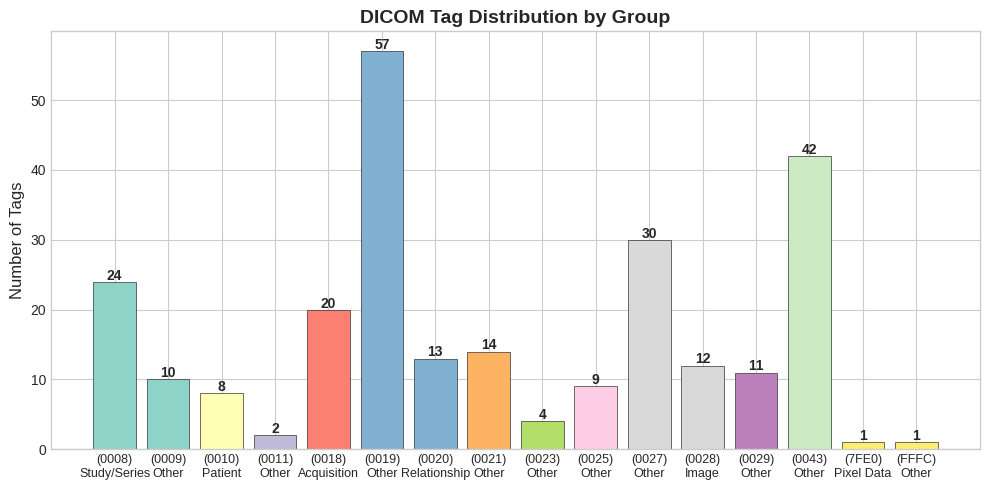


Clinical context: Each tag group serves a different purpose.
Group 0010 = patient identity (must be de-identified for research).
Group 0028 = image parameters (needed for correct display).


In [15]:
# ============================================================
# Section 5b: Iterate and Categorize DICOM Tags
# ============================================================
# DICOM tags are organized by group number:
#   0010 = Patient, 0008 = Study/Series, 0028 = Image, etc.

if ds is not None:
    # Count tags by group
    group_counts = {}
    group_names = {
        "0008": "Study/Series",
        "0010": "Patient",
        "0018": "Acquisition",
        "0020": "Relationship",
        "0028": "Image",
        "0032": "Study",
        "0040": "Procedure",
        "7FE0": "Pixel Data",
    }

    for elem in ds:
        group = f"{elem.tag.group:04X}"
        group_counts[group] = group_counts.get(group, 0) + 1

    print("DICOM Tag Distribution by Group")
    print("=" * 65)
    print(f"{'Group':<8} {'Category':<20} {'Count':<8}")
    print("-" * 40)
    for group in sorted(group_counts.keys()):
        name = group_names.get(group, "Other")
        count = group_counts[group]
        bar = "#" * min(count, 30)
        print(f"({group})  {name:<20} {count:<4} {bar}")

    total_tags = sum(group_counts.values())
    print(f"{'':8} {'TOTAL':<20} {total_tags}")

    # Visualize tag distribution
    fig, ax = plt.subplots(figsize=(10, 5))
    groups = sorted(group_counts.keys())
    counts = [group_counts[g] for g in groups]
    labels = [f"({g})\n{group_names.get(g, 'Other')}" for g in groups]
    colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))

    bars = ax.bar(range(len(groups)), counts, color=colors, edgecolor="#333", linewidth=0.5)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels, fontsize=9, rotation=0)
    ax.set_ylabel("Number of Tags", fontsize=12)
    ax.set_title("DICOM Tag Distribution by Group", fontsize=14, fontweight="bold")

    for bar_item, count in zip(bars, counts):
        ax.text(bar_item.get_x() + bar_item.get_width() / 2, bar_item.get_height() + 0.3,
                str(count), ha="center", fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.show()

    print()
    print("Clinical context: Each tag group serves a different purpose.")
    print("Group 0010 = patient identity (must be de-identified for research).")
    print("Group 0028 = image parameters (needed for correct display).")
else:
    print("DICOM dataset not available for tag analysis.")


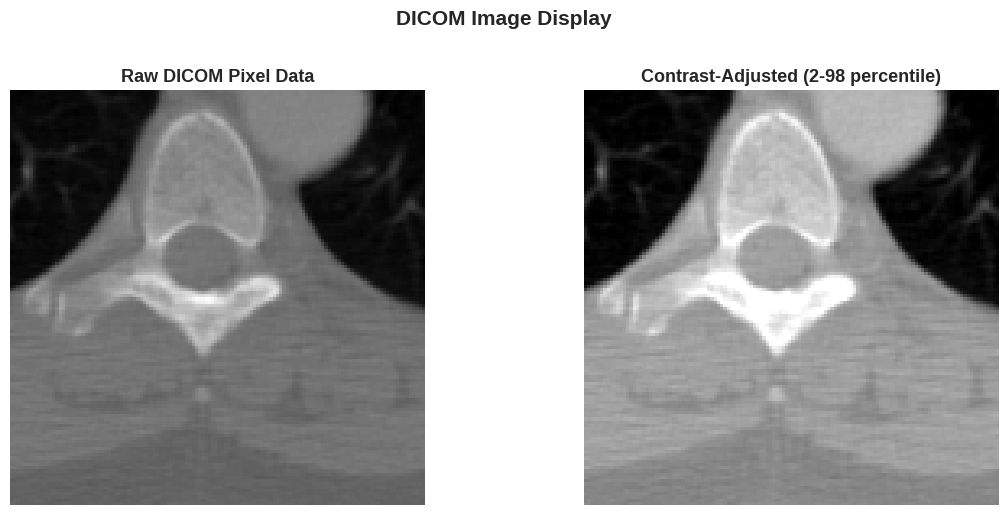

Modality: CT
Image size: 128 x 128 pixels
Pixel range: [128, 2191]

Clinical context: This is what the radiologist sees after
the DICOM file is successfully opened -- the raw medical image.
But to see different tissues clearly, we need WINDOWING.


In [16]:
# ============================================================
# Section 5c: Display the DICOM Image
# ============================================================
# Basic display of the DICOM pixel data using matplotlib.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw pixel values
axes[0].imshow(pixel_array, cmap="gray")
axes[0].set_title("Raw DICOM Pixel Data", fontsize=13, fontweight="bold")
axes[0].axis("off")

# With adjusted contrast
p2, p98 = np.percentile(pixel_array, (2, 98))
axes[1].imshow(pixel_array, cmap="gray", vmin=p2, vmax=p98)
axes[1].set_title("Contrast-Adjusted (2-98 percentile)", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.suptitle("DICOM Image Display", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

if ds is not None:
    modality = ds.get("Modality", "Unknown")
    print(f"Modality: {modality}")
    print(f"Image size: {pixel_array.shape[0]} x {pixel_array.shape[1]} pixels")
    print(f"Pixel range: [{pixel_array.min()}, {pixel_array.max()}]")
print()
print("Clinical context: This is what the radiologist sees after")
print("the DICOM file is successfully opened -- the raw medical image.")
print("But to see different tissues clearly, we need WINDOWING.")


## 6. DICOM Windowing and Display

A CT image stores **Hounsfield Units (HU)** ranging from -1000 (air) to
+3000 (dense bone/metal). But a computer screen displays only 256 gray
levels. **Windowing** (also called window/level) selects WHICH range of
HU values to display:

| Window Setting | Center (WC) | Width (WW) | Shows |
|---------------|-------------|------------|-------|
| Lung | -600 | 1500 | Air-filled structures, lung parenchyma |
| Bone | 400 | 1800 | Skeletal structures, calcifications |
| Soft Tissue | 40 | 400 | Organs, muscles, fluid collections |
| Brain | 40 | 80 | Subtle gray/white matter differences |

**Same image, completely different appearance.** A lung nodule visible in
lung window may be invisible in bone window, and vice versa.

This is why the cardiologist needed proper DICOM viewer software -- not
just "open the image," but "open it with the RIGHT window settings."

> **Corresponds to Lab 2, Slide S56**


In [17]:
# ============================================================
# Section 6a: Apply Rescale Slope and Intercept
# ============================================================
# CT DICOM files store raw detector values. To convert to
# Hounsfield Units: HU = pixel_value * RescaleSlope + RescaleIntercept

if ds is not None:
    rescale_slope = float(ds.get("RescaleSlope", 1))
    rescale_intercept = float(ds.get("RescaleIntercept", 0))
else:
    rescale_slope = 1.0
    rescale_intercept = -1024.0

hu_image = pixel_array.astype(np.float64) * rescale_slope + rescale_intercept

print("Conversion to Hounsfield Units (HU)")
print("=" * 65)
print(f"  Rescale Slope:     {rescale_slope}")
print(f"  Rescale Intercept: {rescale_intercept}")
print(f"  Raw pixel range:   [{pixel_array.min()}, {pixel_array.max()}]")
print(f"  HU range:          [{hu_image.min():.0f}, {hu_image.max():.0f}]")
print()
print("Hounsfield Unit reference values:")
print(f"  Air:        -1000 HU")
print(f"  Lung:       -700 to -500 HU")
print(f"  Fat:        -100 to -50 HU")
print(f"  Water:       0 HU")
print(f"  Soft tissue: 20-80 HU")
print(f"  Bone:        400-1000 HU")
print(f"  Metal:       1000+ HU")


Conversion to Hounsfield Units (HU)
  Rescale Slope:     1.0
  Rescale Intercept: -1024.0
  Raw pixel range:   [128, 2191]
  HU range:          [-896, 1167]

Hounsfield Unit reference values:
  Air:        -1000 HU
  Lung:       -700 to -500 HU
  Fat:        -100 to -50 HU
  Water:       0 HU
  Soft tissue: 20-80 HU
  Bone:        400-1000 HU
  Metal:       1000+ HU


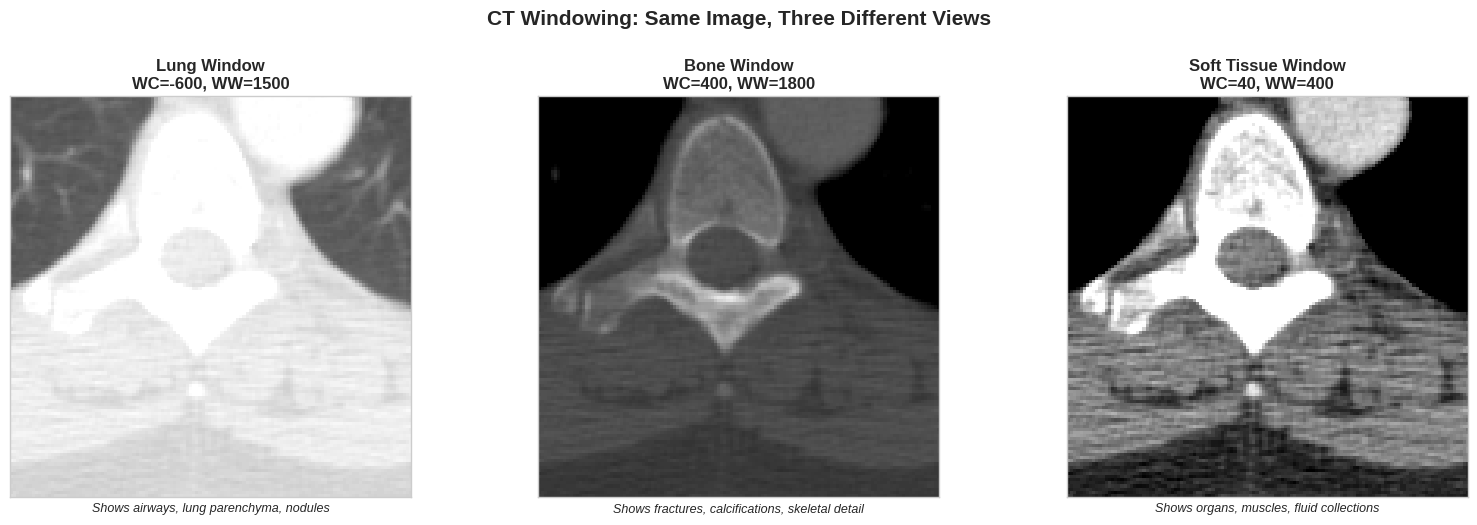

Same pixel data, completely different clinical information visible.
A radiologist switches windows dozens of times while reading a CT.

Clinical context: If Hospital B could not open the DICOM file,
the cardiologist could not apply these windows to look for
aortic dissection, coronary calcification, or lung pathology.


In [18]:
# ============================================================
# Section 6b: Apply Window Center/Width and Display 3 Windows
# ============================================================
# This is the key clinical visualization -- the same CT data
# viewed through three different "windows."

def apply_window(image, center, width):
    """Apply DICOM windowing to a Hounsfield Unit image.

    Args:
        image: 2D array in Hounsfield Units
        center: window center (WC)
        width: window width (WW)

    Returns:
        Windowed image scaled to [0, 1]
    """
    lower = center - width / 2
    upper = center + width / 2
    windowed = np.clip(image, lower, upper)
    windowed = (windowed - lower) / (upper - lower)
    return windowed

# Three standard CT window settings
windows = [
    ("Lung Window", -600, 1500, "Shows airways, lung parenchyma, nodules"),
    ("Bone Window", 400, 1800, "Shows fractures, calcifications, skeletal detail"),
    ("Soft Tissue Window", 40, 400, "Shows organs, muscles, fluid collections"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, wc, ww, description) in zip(axes, windows):
    windowed = apply_window(hu_image, wc, ww)
    ax.imshow(windowed, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{name}\nWC={wc}, WW={ww}", fontsize=12, fontweight="bold")
    ax.set_xlabel(description, fontsize=9, style="italic")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("CT Windowing: Same Image, Three Different Views",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Same pixel data, completely different clinical information visible.")
print("A radiologist switches windows dozens of times while reading a CT.")
print()
print("Clinical context: If Hospital B could not open the DICOM file,")
print("the cardiologist could not apply these windows to look for")
print("aortic dissection, coronary calcification, or lung pathology.")


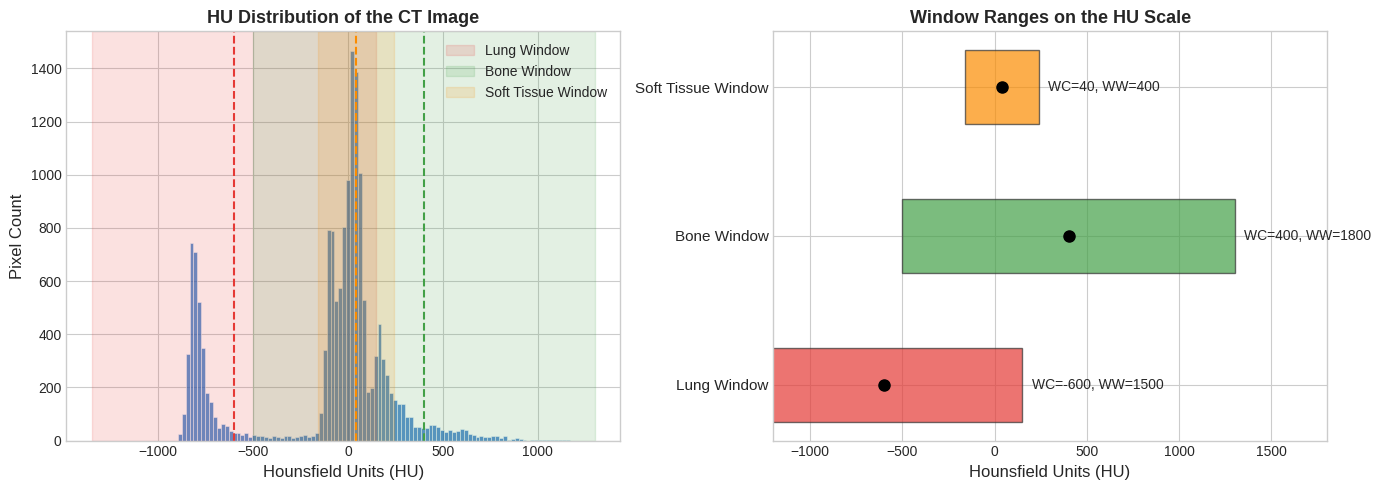

Each window selects a narrow band of the full HU range.
This is why radiologists need proper DICOM viewers, not JPEG exports.


In [19]:
# ============================================================
# Section 6c: Window Comparison — Pixel Intensity Distribution
# ============================================================
# Visualize how each window selects a different range of HU values.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of HU values
axes[0].hist(hu_image.flatten(), bins=100, color="#1565C0", alpha=0.7,
             edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Hounsfield Units (HU)", fontsize=12)
axes[0].set_ylabel("Pixel Count", fontsize=12)
axes[0].set_title("HU Distribution of the CT Image", fontsize=13, fontweight="bold")

# Overlay window ranges
window_colors = ["#E53935", "#43A047", "#FB8C00"]
for (name, wc, ww, _), color in zip(windows, window_colors):
    lower = wc - ww / 2
    upper = wc + ww / 2
    axes[0].axvspan(lower, upper, alpha=0.15, color=color, label=f"{name}")
    axes[0].axvline(wc, color=color, linestyle="--", linewidth=1.5)

axes[0].legend(fontsize=10, loc="upper right")

# Show window ranges as bars
window_names = [w[0] for w in windows]
centers = [w[1] for w in windows]
widths = [w[2] for w in windows]
lowers = [c - w / 2 for c, w in zip(centers, widths)]

for i, (name, wc, ww, _) in enumerate(windows):
    lower = wc - ww / 2
    upper = wc + ww / 2
    axes[1].barh(i, ww, left=lower, height=0.5, color=window_colors[i],
                  alpha=0.7, edgecolor="#333")
    axes[1].plot(wc, i, "ko", markersize=8)
    axes[1].text(upper + 50, i, f"WC={wc}, WW={ww}", fontsize=10, va="center")

axes[1].set_yticks(range(len(windows)))
axes[1].set_yticklabels(window_names, fontsize=11)
axes[1].set_xlabel("Hounsfield Units (HU)", fontsize=12)
axes[1].set_title("Window Ranges on the HU Scale", fontsize=13, fontweight="bold")
axes[1].set_xlim(-1200, 1800)

plt.tight_layout()
plt.show()

print("Each window selects a narrow band of the full HU range.")
print("This is why radiologists need proper DICOM viewers, not JPEG exports.")


## 7. DICOM De-identification

Before sharing DICOM files for research or AI training, **privacy-sensitive
tags MUST be removed**. DICOM headers contain:
- Patient Name, Patient ID, Birth Date
- Hospital name, referring physician
- Study dates, accession numbers

**De-identification** (also called anonymization) removes or replaces these
tags while preserving the medical image and acquisition parameters needed
for analysis.

**Caution:** Some DICOM images have patient information **burned into the
pixel data** (e.g., an overlay showing the patient's name on the image).
Tag removal alone does not catch this -- pixel-level redaction is also needed.

This is critical for building AI training datasets: you need the images,
but you must protect patient privacy.

> **Corresponds to Lab 2, Slide S57**


In [20]:
# ============================================================
# Section 7a: Identify Privacy-Sensitive DICOM Tags
# ============================================================
# Show which tags contain Protected Health Information (PHI).

if ds is not None:
    phi_tags = [
        ("PatientName", "(0010,0010)", "Direct identifier"),
        ("PatientID", "(0010,0020)", "Direct identifier"),
        ("PatientBirthDate", "(0010,0030)", "Date element"),
        ("PatientSex", "(0010,0040)", "Demographic"),
        ("InstitutionName", "(0008,0080)", "Institutional"),
        ("ReferringPhysicianName", "(0008,0090)", "Provider"),
        ("StudyDate", "(0008,0020)", "Date element"),
        ("AccessionNumber", "(0008,0050)", "Institutional"),
    ]

    print("Privacy-Sensitive DICOM Tags (PHI)")
    print("=" * 65)
    print(f"{'Tag Name':<28} {'Tag ID':<14} {'Type':<18} {'Value'}")
    print("-" * 75)

    for tag_name, tag_id, phi_type in phi_tags:
        value = str(ds.get(tag_name, "N/A"))
        if len(value) > 25:
            value = value[:22] + "..."
        print(f"{tag_name:<28} {tag_id:<14} {phi_type:<18} {value}")

    print()
    print(f"Total tags in file: {len(list(ds))}")
    print(f"PHI tags shown:     {len(phi_tags)}")
    print()
    print("These tags MUST be removed before sharing for research or AI training.")
else:
    print("DICOM dataset not available. Showing tag names only.")
    print("Key PHI tags: PatientName, PatientID, PatientBirthDate,")
    print("InstitutionName, ReferringPhysicianName, StudyDate")


Privacy-Sensitive DICOM Tags (PHI)
Tag Name                     Tag ID         Type               Value
---------------------------------------------------------------------------
PatientName                  (0010,0010)    Direct identifier  CompressedSamples^CT1
PatientID                    (0010,0020)    Direct identifier  1CT1
PatientBirthDate             (0010,0030)    Date element       
PatientSex                   (0010,0040)    Demographic        O
InstitutionName              (0008,0080)    Institutional      JFK IMAGING CENTER
ReferringPhysicianName       (0008,0090)    Provider           
StudyDate                    (0008,0020)    Date element       20040119
AccessionNumber              (0008,0050)    Institutional      

Total tags in file: 258
PHI tags shown:     8

These tags MUST be removed before sharing for research or AI training.


In [21]:
# ============================================================
# Section 7b: De-identify a DICOM File
# ============================================================
# Remove or replace privacy-sensitive tags, then save a clean copy.

import copy

if ds is not None:
    # Create a deep copy so we do not modify the original
    ds_anon = copy.deepcopy(ds)

    # Tags to remove or anonymize
    tags_to_anonymize = {
        "PatientName": "ANONYMOUS",
        "PatientID": "ANON_001",
        "PatientBirthDate": "",
        "InstitutionName": "ANONYMOUS_HOSPITAL",
        "ReferringPhysicianName": "",
        "AccessionNumber": "",
    }

    print("De-identification Process")
    print("=" * 65)
    print(f"{'Tag':<28} {'Original':<25} {'Anonymized'}")
    print("-" * 75)

    for tag_name, anon_value in tags_to_anonymize.items():
        original = str(ds_anon.get(tag_name, "N/A"))
        if len(original) > 24:
            original = original[:21] + "..."
        if hasattr(ds_anon, tag_name):
            setattr(ds_anon, tag_name, anon_value)
        print(f"{tag_name:<28} {original:<25} {anon_value if anon_value else '[REMOVED]'}")

    # Save anonymized file
    anon_path = "/tmp/ct_anonymized.dcm"
    ds_anon.save_as(anon_path)

    print()
    print(f"Anonymized file saved to: {anon_path}")
    print(f"Original file size:    {os.path.getsize(ct_file):,} bytes")
    print(f"Anonymized file size:  {os.path.getsize(anon_path):,} bytes")
    print()
    print("Pixel data is PRESERVED -- only metadata tags are modified.")
    print("The image is identical; the patient identity is removed.")

    # Verify anonymization
    print()
    print("Verification -- reading anonymized file:")
    ds_verify = pydicom.dcmread(anon_path)
    print(f"  Patient Name: {ds_verify.PatientName}")
    print(f"  Patient ID:   {ds_verify.PatientID}")
    print(f"  Pixel shape:  {ds_verify.pixel_array.shape} (unchanged)")
else:
    print("DICOM dataset not available for de-identification demo.")
    print()
    print("The de-identification process:")
    print("  1. Load DICOM file with pydicom.dcmread()")
    print("  2. Set PHI tags to anonymous values or empty strings")
    print("  3. Save with ds.save_as('anonymized.dcm')")
    print("  4. Verify: re-read and check that PHI is removed")

print()
print("Clinical context: Before building the AI models from Weeks 3-9,")
print("someone had to de-identify thousands of DICOM files like this.")
print("De-identification is the gateway between clinical care and research.")


De-identification Process
Tag                          Original                  Anonymized
---------------------------------------------------------------------------
PatientName                  CompressedSamples^CT1     ANONYMOUS
PatientID                    1CT1                      ANON_001
PatientBirthDate                                       [REMOVED]
InstitutionName              JFK IMAGING CENTER        ANONYMOUS_HOSPITAL
ReferringPhysicianName                                 [REMOVED]
AccessionNumber                                        [REMOVED]

Anonymized file saved to: /tmp/ct_anonymized.dcm
Original file size:    39,206 bytes
Anonymized file size:  39,198 bytes

Pixel data is PRESERVED -- only metadata tags are modified.
The image is identical; the patient identity is removed.

Verification -- reading anonymized file:
  Patient Name: ANONYMOUS
  Patient ID:   ANON_001
  Pixel shape:  (128, 128) (unchanged)

Clinical context: Before building the AI models from Weeks 3-

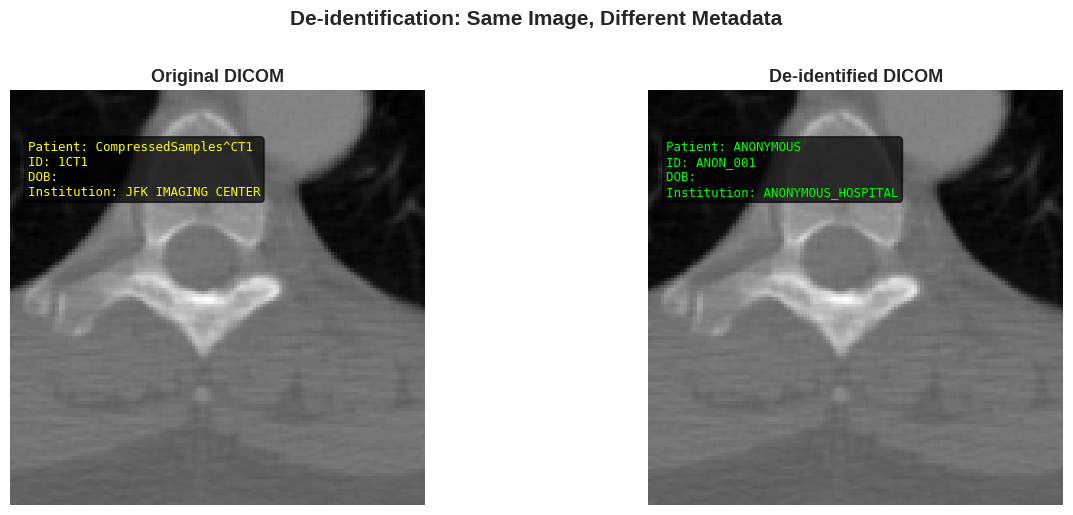

The image is pixel-identical. Only the metadata has changed.
This is the minimum required step before sharing for research.


In [22]:
# ============================================================
# Section 7c: Visualize Original vs Anonymized Metadata
# ============================================================
# Side-by-side comparison of metadata before and after de-identification.

if ds is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Original image with metadata overlay
    axes[0].imshow(ds.pixel_array, cmap="gray")
    axes[0].set_title("Original DICOM", fontsize=13, fontweight="bold")
    meta_text_orig = (
        f"Patient: {ds.get('PatientName', 'N/A')}\n"
        f"ID: {ds.get('PatientID', 'N/A')}\n"
        f"DOB: {ds.get('PatientBirthDate', 'N/A')}\n"
        f"Institution: {ds.get('InstitutionName', 'N/A')}"
    )
    axes[0].text(5, 15, meta_text_orig, fontsize=9, color="yellow",
                  verticalalignment="top", family="monospace",
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7))
    axes[0].axis("off")

    # Anonymized image with metadata overlay
    ds_verify = pydicom.dcmread(anon_path)
    axes[1].imshow(ds_verify.pixel_array, cmap="gray")
    axes[1].set_title("De-identified DICOM", fontsize=13, fontweight="bold")
    meta_text_anon = (
        f"Patient: {ds_verify.get('PatientName', 'N/A')}\n"
        f"ID: {ds_verify.get('PatientID', 'N/A')}\n"
        f"DOB: {ds_verify.get('PatientBirthDate', '[REMOVED]')}\n"
        f"Institution: {ds_verify.get('InstitutionName', 'N/A')}"
    )
    axes[1].text(5, 15, meta_text_anon, fontsize=9, color="lime",
                  verticalalignment="top", family="monospace",
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7))
    axes[1].axis("off")

    plt.suptitle("De-identification: Same Image, Different Metadata",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print("The image is pixel-identical. Only the metadata has changed.")
    print("This is the minimum required step before sharing for research.")
else:
    print("DICOM files not available for visualization.")


## 8. Student Tasks

Complete these exercises to deepen your understanding of FHIR and DICOM.
Each task builds on the code from previous sections.

| Task | Description | Difficulty |
|------|-------------|------------|
| 1 | List all DICOM tags and categorize by group | ⭐ |
| 2 | Apply 3 different CT window settings side by side | ⭐ |
| 3 | Build a FHIR Observation from DICOM metadata | ⭐⭐ |
| 4 | Load DICOM series, reconstruct 3D volume | ⭐⭐ |
| 5 | Query HAPI FHIR, construct mock ImagingStudy | ⭐⭐⭐ |

> **Corresponds to Lab 2, Slide S58**


In [34]:
# ============================================================
# Task 1 (⭐): List All DICOM Tags by Group
# ============================================================
# Objective: Iterate all tags in a DICOM file, print each with its
# group, element, VR (value representation), and value.
#
# Hint: Use ds.iterall() to get every tag including nested sequences.
#       Tag group: elem.tag.group (integer, use f"{elem.tag.group:04X}")
#       Tag element: elem.tag.element
#       VR: elem.VR
#       Value: elem.value (may be very long for pixel data)
#
# Expected output:
#   (0008,0005) CS  SpecificCharacterSet    = ISO_IR 100
#   (0008,0008) CS  ImageType              = [...]
#   (0008,0016) UI  SOPClassUID            = 1.2.840.10008.5.1.4.1.1.2
#   ...
#   Group 0008 (Study/Series):  XX tags
#   Group 0010 (Patient):       XX tags
#   Group 0028 (Image):         XX tags

# YOUR CODE HERE
# for elem in ds:
#     group = f"{elem.tag.group:04X}"
#     element = f"{elem.tag.element:04X}"
#     ...
print("Task 1: List all DICOM tags by group")
print("Write your code above to iterate and categorize tags.")

from collections import defaultdict

print("Task 1: List all DICOM tags by group")

group_counts = defaultdict(int)

for elem in ds.iterall():
    group = f"{elem.tag.group:04X}"
    element = f"{elem.tag.element:04X}"
    vr = elem.VR
    name = elem.name
    value = elem.value

    # (may be very long for pixel data)
    value_str = str(value)
    if len(value_str) > 100:
        value_str = value_str[:100] + " ..."

    print(f"({group},{element}) {vr:<3} {name:<30} = {value_str}")

    group_counts[group] += 1

print("\nTag count by group:")

group_names = {
    "0008": "Study/Series",
    "0010": "Patient",
    "0018": "Acquisition",
    "0020": "Study/Image",
    "0028": "Image",
    "7FE0": "Pixel Data",
}

for group, count in sorted(group_counts.items()):
    label = group_names.get(group, "Other")
    print(f"Group {group} ({label}): {count} tags")




Task 1: List all DICOM tags by group
Write your code above to iterate and categorize tags.
Task 1: List all DICOM tags by group
(0008,0005) CS  Specific Character Set         = ISO_IR 100
(0008,0008) CS  Image Type                     = ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) DA  Instance Creation Date         = 20040119
(0008,0013) TM  Instance Creation Time         = 072731
(0008,0014) UI  Instance Creator UID           = 1.3.6.1.4.1.5962.3
(0008,0016) UI  SOP Class UID                  = 1.2.840.10008.5.1.4.1.1.2
(0008,0018) UI  SOP Instance UID               = 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
(0008,0020) DA  Study Date                     = 20040119
(0008,0021) DA  Series Date                    = 19970430
(0008,0022) DA  Acquisition Date               = 19970430
(0008,0023) DA  Content Date                   = 19970430
(0008,0030) TM  Study Time                     = 072730
(0008,0031) TM  Series Time                    = 112749
(0008,0032) TM  Acquisition Time

Task 2: Apply 3 CT window settings
Write your code above using apply_window().
Task 2: Apply 3 CT window settings


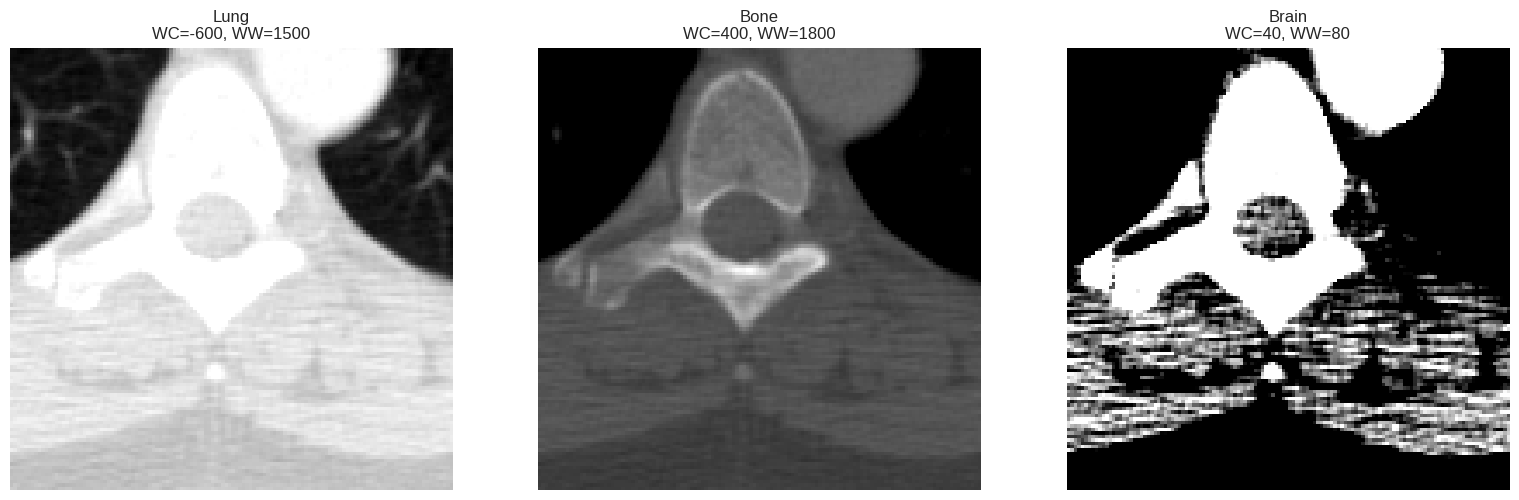

In [35]:
# ============================================================
# Task 2 (⭐): Apply 3 CT Window Settings Side by Side
# ============================================================
# Objective: Apply lung, bone, and brain window settings to the
# CT image and display all three side by side.
#
# Hint: Use the apply_window() function from Section 6.
#   Lung:   WC=-600, WW=1500
#   Bone:   WC=400,  WW=1800
#   Brain:  WC=40,   WW=80
#
# Use fig, axes = plt.subplots(1, 3, figsize=(16, 5))
#
# Expected output: 3 images showing very different anatomy

# YOUR CODE HERE
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# for ax, (name, wc, ww) in zip(axes, [("Lung", -600, 1500), ...]):
#     windowed = apply_window(hu_image, wc, ww)
#     ax.imshow(windowed, cmap="gray")
#     ...
print("Task 2: Apply 3 CT window settings")
print("Write your code above using apply_window().")

print("Task 2: Apply 3 CT window settings")

windows = [
    ("Lung", -600, 1500),
    ("Bone", 400, 1800),
    ("Brain", 40, 80),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, wc, ww) in zip(axes, windows):
    windowed = apply_window(hu_image, wc, ww)

    ax.imshow(windowed, cmap="gray")
    ax.set_title(f"{name}\nWC={wc}, WW={ww}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [37]:
# ============================================================
# Task 3 (⭐⭐): Build a FHIR Observation from DICOM Metadata
# ============================================================
# Objective: Extract patient ID, modality, and study date from a
# DICOM file, then construct a FHIR Observation resource.
#
# Hint:
#   1. Read DICOM: patient_id = ds.PatientID, modality = ds.Modality
#   2. Build Observation JSON:
#      - resourceType: "Observation"
#      - status: "final"
#      - code: use a descriptive text like "Imaging Study Performed"
#      - subject: reference to Patient/{patient_id}
#      - valueString: f"Modality: {modality}, Date: {study_date}"
#   3. Print the JSON
#
# Expected output: A valid FHIR Observation JSON linking DICOM metadata

# YOUR CODE HERE
# if ds is not None:
#     dicom_patient_id = str(ds.get("PatientID", "unknown"))
#     dicom_modality = str(ds.get("Modality", "unknown"))
#     dicom_date = str(ds.get("StudyDate", "unknown"))
#     obs_from_dicom = { "resourceType": "Observation", ... }
#     print(json.dumps(obs_from_dicom, indent=2))
print("Task 3: Build FHIR Observation from DICOM metadata")
print("Write your code above to bridge DICOM -> FHIR.")


import json

print("Task 3: Build FHIR Observation from DICOM metadata")

if ds is not None:
    dicom_patient_id = str(ds.get("PatientID", "unknown"))
    dicom_modality = str(ds.get("Modality", "unknown"))
    dicom_date = str(ds.get("StudyDate", "unknown"))

    obs_from_dicom = {
      "resourceType": "Observation",
      "status": "final",
      "code": {
          "text": "Imaging Study Performed"
      },
      "subject": {
          "reference": f"Patient/{dicom_patient_id}"
      },
      "effectiveDateTime": dicom_date,
      "valueString": f"Modality: {dicom_modality}"
    }

    print(json.dumps(obs_from_dicom, indent=2))
else:
    print("No DICOM dataset loaded.")

Task 3: Build FHIR Observation from DICOM metadata
Write your code above to bridge DICOM -> FHIR.
Task 3: Build FHIR Observation from DICOM metadata
{
  "resourceType": "Observation",
  "status": "final",
  "code": {
    "text": "Imaging Study Performed"
  },
  "subject": {
    "reference": "Patient/1CT1"
  },
  "effectiveDateTime": "20040119",
  "valueString": "Modality: CT"
}


Task 4: Reconstruct 3D volume from DICOM slices
Write your code above to create and display 3 orthogonal views.
Task 4: Reconstruct 3D volume from DICOM slices
3D Volume shape: (30, 128, 128)


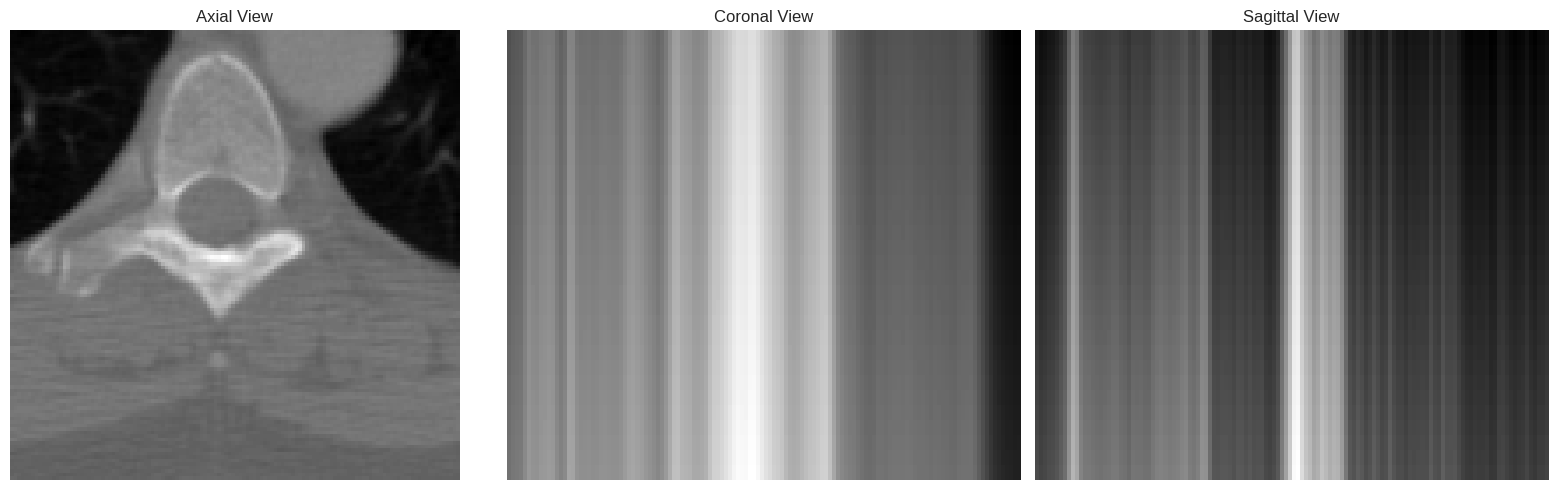

In [38]:
# ============================================================
# Task 4 (⭐⭐): Load DICOM Series, Reconstruct 3D Volume
# ============================================================
# Objective: Load multiple DICOM slices and stack them into a 3D
# volume. Display axial, coronal, and sagittal views.
#
# Note: pydicom test files only include single slices. For this
# task, we create a synthetic 3D volume by stacking the single
# slice with slight variations.
#
# Hint:
#   1. Create volume: volume = np.stack([pixel_array + i*10 for i in range(30)])
#   2. Display 3 views:
#      - Axial: volume[15, :, :]  (one slice)
#      - Coronal: volume[:, 64, :]  (front view)
#      - Sagittal: volume[:, :, 64]  (side view)
#   3. Use fig, axes = plt.subplots(1, 3, figsize=(16, 5))
#
# Expected output: 3 orthogonal views of the 3D volume

# YOUR CODE HERE
# volume = np.stack([pixel_array + i * 10 for i in range(30)])
# print(f"3D Volume shape: {volume.shape}")
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# axes[0].imshow(volume[15, :, :], cmap="gray")
# ...
print("Task 4: Reconstruct 3D volume from DICOM slices")
print("Write your code above to create and display 3 orthogonal views.")

print("Task 4: Reconstruct 3D volume from DICOM slices")

# Build 30 slices
volume = np.stack([pixel_array + i * 10 for i in range(30)])

print(f"3D Volume shape: {volume.shape}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Axial view
axes[0].imshow(volume[15, :, :], cmap="gray")
axes[0].set_title("Axial View")
axes[0].axis("off")

# Coronal view
axes[1].imshow(volume[:, 64, :], cmap="gray", aspect="auto")
axes[1].set_title("Coronal View")
axes[1].axis("off")

# Sagittal view
axes[2].imshow(volume[:, :, 64], cmap="gray", aspect="auto")
axes[2].set_title("Sagittal View")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [39]:
# ============================================================
# Task 5 (⭐⭐⭐): Query FHIR + Construct Mock ImagingStudy
# ============================================================
# Objective: Query HAPI FHIR for a patient, then construct a mock
# ImagingStudy resource linking that patient to DICOM UIDs.
#
# Hint:
#   1. Search for a patient: GET /Patient?name=Smith&_count=1
#   2. Extract patient ID from the response
#   3. Construct an ImagingStudy resource:
#      {
#        "resourceType": "ImagingStudy",
#        "status": "available",
#        "subject": {"reference": f"Patient/{patient_id}"},
#        "started": "2026-02-08T08:00:00Z",
#        "numberOfSeries": 1,
#        "numberOfInstances": 1,
#        "series": [{
#            "uid": "1.2.840.113619.2.55.3.2831185921.123.1234567890.1",
#            "modality": {"system": "http://dicom.nema.org/resources/ontology/DCM", "code": "CT"},
#            "numberOfInstances": 1,
#            "instance": [{
#                "uid": "1.2.840.113619.2.55.3.2831185921.123.1234567890.1.1",
#                "sopClass": {"system": "urn:ietf:rfc:3986",
#                             "code": "urn:oid:1.2.840.10008.5.1.4.1.1.2"}
#            }]
#        }]
#      }
#   4. Print the complete ImagingStudy JSON
#
# Expected output: A FHIR ImagingStudy linking Patient to DICOM UIDs

# YOUR CODE HERE
print("Task 5: Query FHIR + construct ImagingStudy")
print("Write your code above to bridge FHIR Patient -> DICOM imaging.")

import requests
import json

print("Task 5: Query FHIR + construct ImagingStudy")

# HAPI FHIR public test server
BASE_URL = "https://hapi.fhir.org/baseR4"

# 1. Search for patient Smith
response = requests.get(
    f"{BASE_URL}/Patient",
    params={
        "name": "Smith",
        "_count": 1
    }
)

data = response.json()

# 2. Extract patient ID
if "entry" in data and len(data["entry"]) > 0:
    patient = data["entry"][0]["resource"]
    patient_id = patient["id"]

    # 3. Construct mock ImagingStudy
    imaging_study = {
        "resourceType": "ImagingStudy",
        "status": "available",
        "subject": {
            "reference": f"Patient/{patient_id}"
        },
        "started": "2026-02-08T08:00:00Z",
        "numberOfSeries": 1,
        "numberOfInstances": 1,
        "series": [
            {
                "uid": "1.2.840.113619.2.55.3.2831185921.123.1234567890.1",
                "modality": {
                    "system": "http://dicom.nema.org/resources/ontology/DCM",
                    "code": "CT"
                },
                "numberOfInstances": 1,
                "instance": [
                    {
                        "uid": "1.2.840.113619.2.55.3.2831185921.123.1234567890.1.1",
                        "sopClass": {
                            "system": "urn:ietf:rfc:3986",
                            "code": "urn:oid:1.2.840.10008.5.1.4.1.1.2"
                        }
                    }
                ]
            }
        ]
    }

    # 4. Print JSON
    print(json.dumps(imaging_study, indent=2))

else:
    print("No patient found.")

Task 5: Query FHIR + construct ImagingStudy
Write your code above to bridge FHIR Patient -> DICOM imaging.
Task 5: Query FHIR + construct ImagingStudy
{
  "resourceType": "ImagingStudy",
  "status": "available",
  "subject": {
    "reference": "Patient/ailovdisyb2"
  },
  "started": "2026-02-08T08:00:00Z",
  "numberOfSeries": 1,
  "numberOfInstances": 1,
  "series": [
    {
      "uid": "1.2.840.113619.2.55.3.2831185921.123.1234567890.1",
      "modality": {
        "system": "http://dicom.nema.org/resources/ontology/DCM",
        "code": "CT"
      },
      "numberOfInstances": 1,
      "instance": [
        {
          "uid": "1.2.840.113619.2.55.3.2831185921.123.1234567890.1.1",
          "sopClass": {
            "system": "urn:ietf:rfc:3986",
            "code": "urn:oid:1.2.840.10008.5.1.4.1.1.2"
          }
        }
      ]
    }
  ]
}


## 9. Gemini AI Exercise

Use Google Colab's built-in **Gemini AI** to explore healthcare data
standards, code generation for DICOM/FHIR, and integration architecture
design.

These prompts develop the skill of using AI as a **standards expert
consultant** -- asking about which standard to use, how to extract data,
and how to design integration architectures.

> **Corresponds to Lab 2, Slide S59**


In [28]:
# ============================================================
# Section 9a: Gemini Prompt 1 — Compare Standards
# ============================================================
try:
    from google.colab import ai

    print("Gemini Prompt 1: Compare Healthcare Data Standards")
    print("=" * 65)
    response = ai.generate_text(
        "Explain the difference between HL7 v2, HL7 FHIR, and DICOM. "
        "When would a hospital use each standard? Give a concrete "
        "scenario for each. Keep it under 250 words."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("This section works only in Google Colab.")
    print()
    print("Try this prompt manually in the Colab Gemini sidebar:")
    print("-" * 65)
    print('"Explain the difference between HL7 v2, HL7 FHIR, and DICOM.')
    print("When would a hospital use each standard? Give a concrete")
    print('scenario for each. Keep it under 250 words."')


Gemini Prompt 1: Compare Healthcare Data Standards
**HL7 v2** is an older, widely adopted message-based standard using pipe-delimited text for data exchange. Hospitals use it for core administrative and clinical workflows.
*   **Scenario:** When a patient is admitted, the ADT system sends an HL7 v2 message to update the EHR, billing, and lab systems with their registration details.

**HL7 FHIR (Fast Healthcare Interoperability Resources)** is a modern, API-based standard using web technologies (JSON/XML, RESTful APIs). It’s designed for easy access, mobile health, and complex data sharing.
*   **Scenario:** A patient's mobile app queries the hospital's EHR via a FHIR API to securely display their medication list and recent lab results in real-time.

**DICOM (Digital Imaging and Communications in Medicine)** is specifically for medical images and associated information. It defines image formats, storage, and transmission protocols. Hospitals use DICOM to manage all imaging data.
*   **S

In [29]:
# ============================================================
# Section 9b: Gemini Prompt 2 — Generate DICOM Code
# ============================================================
try:
    from google.colab import ai

    print("Gemini Prompt 2: Generate DICOM Extraction Code")
    print("=" * 65)
    response = ai.generate_text(
        "I have a DICOM CT scan file. Write Python code using pydicom "
        "to extract Patient Name, Modality, Study Date, Rows, Columns, "
        "and Pixel Spacing. Then display the image with matplotlib. "
        "Include error handling for missing tags."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print()
    print("Try this prompt manually in the Colab Gemini sidebar:")
    print("-" * 65)
    print('"I have a DICOM CT scan file. Write Python code using pydicom')
    print("to extract Patient Name, Modality, Study Date, Rows, Columns,")
    print("and Pixel Spacing. Then display the image with matplotlib.")
    print('Include error handling for missing tags."')


Gemini Prompt 2: Generate DICOM Extraction Code
Okay, here's a Python script using `pydicom` and `matplotlib` to achieve your goal. It includes robust error handling for missing DICOM tags and demonstrates how to display a CT image.

### Prerequisites

Before running, ensure you have the necessary libraries installed:

```bash
pip install pydicom matplotlib numpy
```

### Python Code

```python
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

def process_dicom_ct_scan(dicom_file_path):
    """
    Extracts specified metadata from a DICOM CT scan and displays the image.

    Args:
        dicom_file_path (str): The path to the DICOM CT file.
    """
    if not os.path.exists(dicom_file_path):
        print(f"Error: File not found at '{dicom_file_path}'")
        sys.exit(1)

    try:
        # Read the DICOM file
        ds = pydicom.dcmread(dicom_file_path)
        print(f"Successfully loaded DICOM file: {os.path.basename(dicom_file_path)}")

    

In [30]:
# ============================================================
# Section 9c: Gemini Prompt 3 — Design Integration Pipeline
# ============================================================
try:
    from google.colab import ai

    print("Gemini Prompt 3: Design Multi-Modal AI Pipeline")
    print("=" * 65)
    response = ai.generate_text(
        "Design a simple multi-modal AI pipeline that combines FHIR "
        "clinical data (lab results, vital signs) with DICOM imaging "
        "data (chest X-ray) for pneumonia prediction. Describe the "
        "data flow step by step, from hospital systems to model "
        "inference. Keep it under 300 words."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print()
    print("Try this prompt manually in the Colab Gemini sidebar:")
    print("-" * 65)
    print('"Design a simple multi-modal AI pipeline that combines FHIR')
    print("clinical data (lab results, vital signs) with DICOM imaging")
    print("data (chest X-ray) for pneumonia prediction. Describe the")
    print("data flow step by step, from hospital systems to model")
    print('inference. Keep it under 300 words."')

print()
print("=" * 65)
print("Key learning: Gemini can serve as a healthcare IT consultant.")
print("Ask about standards selection, code generation, and architecture")
print("design -- but always validate against official specifications.")


Gemini Prompt 3: Design Multi-Modal AI Pipeline
Here's a simple multi-modal AI pipeline for pneumonia prediction:

1.  **Data Ingestion:**
    *   **FHIR:** Hospital EHRs provide structured clinical data (lab results like WBC count, CRP; vital signs like temperature, SpO2) via FHIR APIs or exports.
    *   **DICOM:** PACS systems provide chest X-ray images (DICOM format) via DICOMweb or direct integration.

2.  **FHIR Data Preprocessing:**
    *   FHIR resources (e.g., Observation, Vitalsigns) are parsed.
    *   Relevant numerical clinical features are extracted, normalized, and missing values handled, forming a structured feature vector.

3.  **DICOM Data Preprocessing:**
    *   DICOM images are loaded, anonymized, and preprocessed (e.g., resizing, intensity normalization, contrast adjustment).
    *   A pre-trained Convolutional Neural Network (CNN) extracts high-level image features from the chest X-rays.

4.  **Feature Fusion:**
    *   Patient identifiers are used to align clini

## 10. Bonus: FHIR + DICOM Integration via ImagingStudy

The **ImagingStudy** resource is the bridge between FHIR (clinical data)
and DICOM (imaging data). It stores metadata about a DICOM study without
duplicating the large image files:

**Integration Workflow:**
1. **Discovery**: Query FHIR server: `GET /ImagingStudy?subject=Patient/123`
2. **Metadata**: FHIR returns ImagingStudy with Study/Series/Instance UIDs
3. **Image access**: Use UIDs to construct DICOMweb URL: `GET /dicomweb/studies/{StudyUID}`
4. **Visualization**: Display in viewer or feed to AI pipeline

This separation keeps clinical context in FHIR and image data in DICOM/PACS,
connected by unique identifiers (UIDs).

**For our scenario:** Hospital B queries FHIR for the patient's ImagingStudy,
gets the Study Instance UID, then retrieves the CT via DICOMweb -- no CD needed.

> **Corresponds to Part 4, Slides S61-S63**


In [31]:
# ============================================================
# Section 10a: Construct a Mock ImagingStudy Resource
# ============================================================
# Link our FHIR patient to the DICOM CT scan we loaded in Section 5.

# Extract UIDs from the DICOM file (if available)
if ds is not None:
    study_uid = str(ds.get("StudyInstanceUID", "1.2.840.113619.2.55.3.123456"))
    series_uid = str(ds.get("SeriesInstanceUID", "1.2.840.113619.2.55.3.123456.1"))
    sop_uid = str(ds.get("SOPInstanceUID", "1.2.840.113619.2.55.3.123456.1.1"))
    sop_class = str(ds.get("SOPClassUID", "1.2.840.10008.5.1.4.1.1.2"))
    modality_code = str(ds.get("Modality", "CT"))
else:
    study_uid = "1.2.840.113619.2.55.3.2831185921.123.1234567890"
    series_uid = "1.2.840.113619.2.55.3.2831185921.123.1234567890.1"
    sop_uid = "1.2.840.113619.2.55.3.2831185921.123.1234567890.1.1"
    sop_class = "1.2.840.10008.5.1.4.1.1.2"
    modality_code = "CT"

imaging_study = {
    "resourceType": "ImagingStudy",
    "id": "imaging-study-001",
    "status": "available",
    "subject": {
        "reference": f"Patient/{patient_id}",
        "display": "Chen, Mei-Ling"
    },
    "started": "2026-02-08T08:00:00Z",
    "numberOfSeries": 1,
    "numberOfInstances": 1,
    "description": "CT Angiography Chest",
    "series": [
        {
            "uid": series_uid,
            "number": 1,
            "modality": {
                "system": "http://dicom.nema.org/resources/ontology/DCM",
                "code": modality_code
            },
            "description": "Axial CT Angiography",
            "numberOfInstances": 1,
            "instance": [
                {
                    "uid": sop_uid,
                    "sopClass": {
                        "system": "urn:ietf:rfc:3986",
                        "code": f"urn:oid:{sop_class}"
                    },
                    "number": 1
                }
            ]
        }
    ],
    "identifier": [
        {
            "system": "urn:dicom:uid",
            "value": f"urn:oid:{study_uid}"
        }
    ]
}

print("FHIR ImagingStudy Resource")
print("=" * 65)
print(json.dumps(imaging_study, indent=2))
print()
print("This resource BRIDGES FHIR and DICOM:")
print(f"  FHIR Patient:        Patient/{patient_id}")
print(f"  DICOM Study UID:     {study_uid[:40]}...")
print(f"  DICOM Series UID:    {series_uid[:40]}...")
print(f"  DICOM Instance UID:  {sop_uid[:40]}...")
print(f"  Modality:            {modality_code}")


FHIR ImagingStudy Resource
{
  "resourceType": "ImagingStudy",
  "id": "imaging-study-001",
  "status": "available",
  "subject": {
    "reference": "Patient/2ff0b457-7fe8-4687-9efb-716b9c1f11f7",
    "display": "Chen, Mei-Ling"
  },
  "started": "2026-02-08T08:00:00Z",
  "numberOfSeries": 1,
  "numberOfInstances": 1,
  "description": "CT Angiography Chest",
  "series": [
    {
      "uid": "1.3.6.1.4.1.5962.1.3.1.1.20040119072730.12322",
      "number": 1,
      "modality": {
        "system": "http://dicom.nema.org/resources/ontology/DCM",
        "code": "CT"
      },
      "description": "Axial CT Angiography",
      "numberOfInstances": 1,
      "instance": [
        {
          "uid": "1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322",
          "sopClass": {
            "system": "urn:ietf:rfc:3986",
            "code": "urn:oid:1.2.840.10008.5.1.4.1.1.2"
          },
          "number": 1
        }
      ]
    }
  ],
  "identifier": [
    {
      "system": "urn:dicom:uid",
     

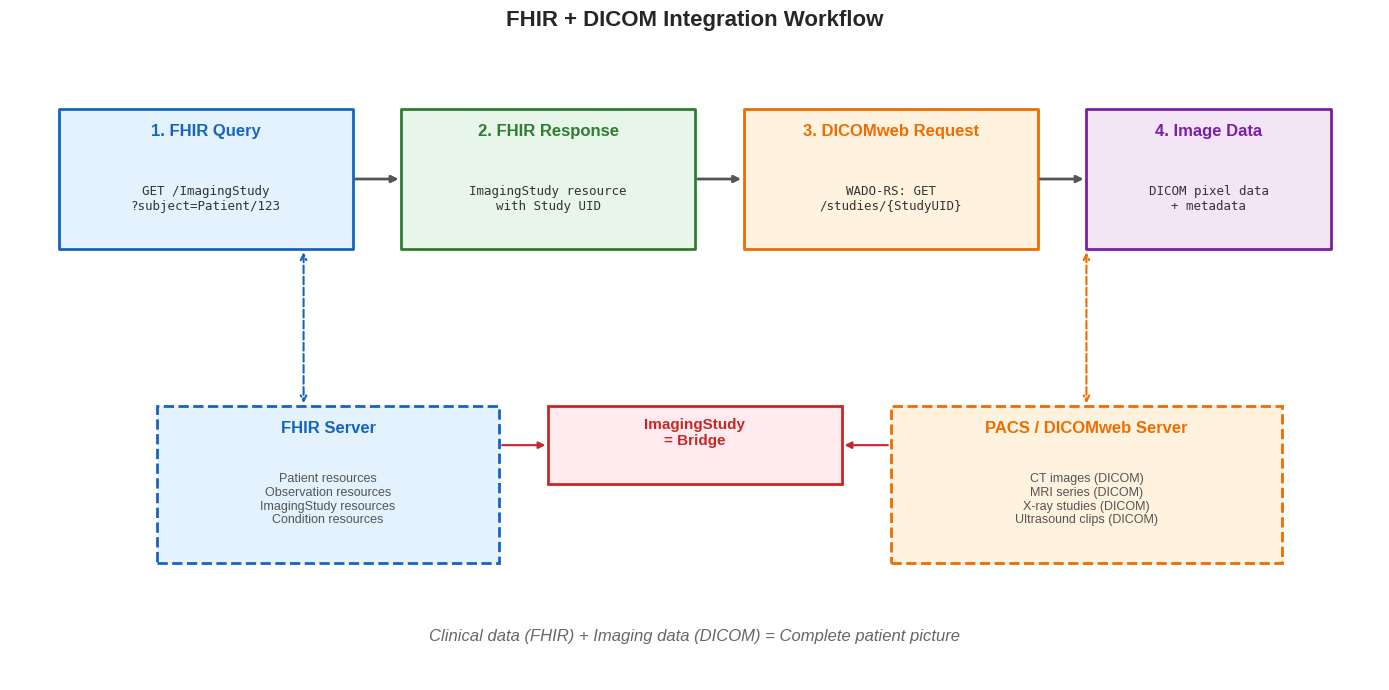

The ImagingStudy resource is the key that unlocks both worlds.
FHIR provides clinical context. DICOM provides pixel data.
Together: the cardiologist has everything she needs.


In [32]:
# ============================================================
# Section 10b: Visualize the FHIR-DICOM Integration Workflow
# ============================================================
# Show how a query flows from FHIR to DICOM and back.

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("FHIR + DICOM Integration Workflow",
             fontsize=16, fontweight="bold", pad=20)

# Step boxes
steps = [
    (0.5, 5.5, 3, 1.8, "1. FHIR Query",
     "GET /ImagingStudy\n?subject=Patient/123",
     "#E3F2FD", "#1565C0"),
    (4, 5.5, 3, 1.8, "2. FHIR Response",
     "ImagingStudy resource\nwith Study UID",
     "#E8F5E9", "#2E7D32"),
    (7.5, 5.5, 3, 1.8, "3. DICOMweb Request",
     "WADO-RS: GET\n/studies/{StudyUID}",
     "#FFF3E0", "#EF6C00"),
    (11, 5.5, 2.5, 1.8, "4. Image Data",
     "DICOM pixel data\n+ metadata",
     "#F3E5F5", "#7B1FA2"),
]

for x, y, w, h, title, content, fc, ec in steps:
    box = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec,
                          linewidth=2, zorder=2, joinstyle="round")
    ax.add_patch(box)
    ax.text(x + w / 2, y + h - 0.35, title, fontsize=12, fontweight="bold",
            ha="center", color=ec)
    ax.text(x + w / 2, y + 0.5, content, fontsize=9, ha="center",
            color="#333333", family="monospace")

# Arrows between steps
arrow_props = dict(arrowstyle="-|>", color="#555555", lw=2)
for i in range(len(steps) - 1):
    x1 = steps[i][0] + steps[i][2]
    x2 = steps[i + 1][0]
    y_mid = steps[i][1] + steps[i][3] / 2
    ax.annotate("", xy=(x2, y_mid), xytext=(x1, y_mid), arrowprops=arrow_props)

# Server boxes at bottom
servers = [
    (1.5, 1.5, 3.5, 2, "FHIR Server",
     "Patient resources\nObservation resources\nImagingStudy resources\nCondition resources",
     "#E3F2FD", "#1565C0"),
    (9, 1.5, 4, 2, "PACS / DICOMweb Server",
     "CT images (DICOM)\nMRI series (DICOM)\nX-ray studies (DICOM)\nUltrasound clips (DICOM)",
     "#FFF3E0", "#EF6C00"),
]

for x, y, w, h, title, content, fc, ec in servers:
    box = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec,
                          linewidth=2, zorder=2, linestyle="--")
    ax.add_patch(box)
    ax.text(x + w / 2, y + h - 0.35, title, fontsize=12, fontweight="bold",
            ha="center", color=ec)
    ax.text(x + w / 2, y + 0.5, content, fontsize=9, ha="center",
            color="#555555")

# Vertical arrows from query to servers
ax.annotate("", xy=(3, 3.5), xytext=(3, 5.5), arrowprops=dict(
    arrowstyle="<->", color="#1565C0", lw=1.5, linestyle="--"))
ax.annotate("", xy=(11, 3.5), xytext=(11, 5.5), arrowprops=dict(
    arrowstyle="<->", color="#EF6C00", lw=1.5, linestyle="--"))

# Label: ImagingStudy bridges both
bridge_box = plt.Rectangle((5.5, 2.5, ), 3, 1, facecolor="#FFEBEE",
                             edgecolor="#C62828", linewidth=2, zorder=3)
ax.add_patch(bridge_box)
ax.text(7, 3.0, "ImagingStudy\n= Bridge", fontsize=11, fontweight="bold",
        ha="center", color="#C62828")

# Arrows from bridge to both servers
ax.annotate("", xy=(5.5, 3.0), xytext=(5, 3.0), arrowprops=dict(
    arrowstyle="-|>", color="#C62828", lw=1.5))
ax.annotate("", xy=(8.5, 3.0), xytext=(9, 3.0), arrowprops=dict(
    arrowstyle="-|>", color="#C62828", lw=1.5))

# Bottom annotation
ax.text(7, 0.5, "Clinical data (FHIR) + Imaging data (DICOM) = Complete patient picture",
        fontsize=12, ha="center", style="italic", color="#666666")

plt.tight_layout()
plt.show()

print("The ImagingStudy resource is the key that unlocks both worlds.")
print("FHIR provides clinical context. DICOM provides pixel data.")
print("Together: the cardiologist has everything she needs.")


## 11. Summary and Self-Check

### Key Takeaways (Matching Slides S73-S74)

1. **Interoperability is a patient safety issue**: When Hospital A cannot share data with Hospital B, patients suffer. The 68-year-old with chest pain waited because systems could not talk to each other. Standards are not boring IT -- they save lives.

2. **FHIR = modern API for clinical data**: Resources (Patient, Observation, Condition) exchanged via RESTful HTTP (GET, POST, PUT, DELETE) in JSON format. Any system that speaks HTTP can speak FHIR. LOINC and SNOMED CT provide semantic coding.

3. **DICOM = the universal imaging standard**: Every medical image (CT, MRI, X-ray) is DICOM. Files bundle pixel data WITH metadata (patient info, acquisition parameters). Tags are organized by group (0010=Patient, 0008=Study, 0028=Image).

4. **Windowing transforms the same data into different views**: A CT stores Hounsfield Units from -1000 to +3000. Lung window, bone window, and soft tissue window reveal completely different anatomy from identical pixel data.

5. **De-identification is the gateway to AI**: Before training any AI model on medical images, patient-identifying tags MUST be removed. pydicom makes this straightforward but pixel-level burned-in text requires additional tools.

6. **ImagingStudy bridges FHIR and DICOM**: The FHIR ImagingStudy resource links clinical context (patient, diagnosis, encounter) to imaging data (Study UID, Series UID, Instance UID). This enables discovery via FHIR and retrieval via DICOMweb.

### Key Numbers (Matching Slide S74)

| Number | Significance |
|--------|-------------|
| 70% | US hospitals engaged in interoperability (but many struggle with routine exchange) |
| 92% | Cite FHIR/API as top-3 procurement priority (2026) |
| 150+ | FHIR resource types defined in the R4 specification |
| (0010,0010) | The DICOM tag for Patient Name -- first tag to de-identify |
| 21st Century Cures Act | US law prohibiting information blocking since 2020 |
| USCDI v3 | Required by January 2026 -- defines minimum data elements for exchange |

### Self-Check Checklist

- [ ] I can explain why interoperability is a patient safety issue, not just an IT problem
- [ ] I can describe the structure of a FHIR Patient and Observation resource in JSON
- [ ] I successfully queried the HAPI FHIR server and retrieved Patient and Observation data
- [ ] I created a new FHIR Observation via HTTP POST
- [ ] I loaded a DICOM file with pydicom and extracted metadata tags
- [ ] I applied CT windowing (lung, bone, soft tissue) and understood the visual differences
- [ ] I de-identified a DICOM file by removing privacy-sensitive tags
- [ ] I can explain how ImagingStudy bridges FHIR clinical data and DICOM imaging data
- [ ] I understand the difference between HL7 v2, FHIR, and DICOM and when each applies

### Next Week Preview

**Week 11: Unsupervised Learning -- Clustering and Dimensionality Reduction**
- This week: STRUCTURED data via standards (FHIR + DICOM)
- Next week: What if the data has NO labels? Unsupervised learning finds hidden structure.
- Clinical scenario: "Some Type 2 diabetes patients respond to metformin, others do not. Maybe 'Type 2 diabetes' is not one disease -- it is three different diseases mixed together. Can clustering find these subtypes?"
- Prepare: Review Week 4 feature preprocessing (scaling, encoding)


In [33]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 65)
print("Congratulations! You have completed the Week 10 Notebook!")
print("Medical Data Standards: FHIR and DICOM")
print("=" * 65)

print()
print("FHIR Exercises Completed:")
print("  1. Explored Patient and Observation JSON resources")
print("  2. Searched HAPI FHIR server for patients by name")
print("  3. Read a specific Patient and their linked Observations")
print("  4. Created a new Observation via HTTP POST")

print()
print("DICOM Exercises Completed:")
print("  5. Loaded a DICOM file and extracted metadata tags")
print("  6. Applied CT windowing (lung, bone, soft tissue)")
print("  7. De-identified a DICOM file for research use")

print()
print("Integration:")
print("  8. Constructed an ImagingStudy resource bridging FHIR + DICOM")
print("  9. Visualized the complete integration workflow")

print()
print("Visualizations produced:")
print("  1. FHIR resource structure diagram")
print("  2. DICOM tag distribution by group (bar chart)")
print("  3. Raw vs contrast-adjusted DICOM image")
print("  4. CT windowing: lung, bone, soft tissue (3 views)")
print("  5. HU distribution with window ranges overlay")
print("  6. Original vs de-identified DICOM metadata comparison")
print("  7. FHIR + DICOM integration workflow diagram")

print()
print("Returning to the hospital transfer scenario:")
print("  The 68-year-old woman with chest pain needed TWO things:")
print("  1. Her clinical data (labs, meds, allergies) via FHIR")
print("  2. Her CT angiography via DICOM")
print("  With interoperable standards, Hospital B gets both in seconds.")
print("  Without them, the cardiologist operates blind.")
print()
print("  Standards are not glamorous -- but they are the infrastructure")
print("  that makes every AI model from Weeks 3-9 possible.")
print()
print("  Next week: Unsupervised Learning -- finding hidden structure")
print("  in unlabeled data. Can clustering reveal diabetes subtypes?")


Congratulations! You have completed the Week 10 Notebook!
Medical Data Standards: FHIR and DICOM

FHIR Exercises Completed:
  1. Explored Patient and Observation JSON resources
  2. Searched HAPI FHIR server for patients by name
  3. Read a specific Patient and their linked Observations
  4. Created a new Observation via HTTP POST

DICOM Exercises Completed:
  5. Loaded a DICOM file and extracted metadata tags
  6. Applied CT windowing (lung, bone, soft tissue)
  7. De-identified a DICOM file for research use

Integration:
  8. Constructed an ImagingStudy resource bridging FHIR + DICOM
  9. Visualized the complete integration workflow

Visualizations produced:
  1. FHIR resource structure diagram
  2. DICOM tag distribution by group (bar chart)
  3. Raw vs contrast-adjusted DICOM image
  4. CT windowing: lung, bone, soft tissue (3 views)
  5. HU distribution with window ranges overlay
  6. Original vs de-identified DICOM metadata comparison
  7. FHIR + DICOM integration workflow diagra